# Credit Risk & Loan Approval Intelligence Platform

### Author: Jasmeet Singh Bhatia
---
## Objective

Develop a machine learning solution that predicts loan approval and estimates applicant credit risk while providing explainable insights for financial institutions.

# Business Understanding

Banks process thousands of loan applications every day. Approving loans for applicants who are likely to default can lead to significant financial losses, while rejecting creditworthy applicants reduces revenue and customer satisfaction.

This project aims to build an intelligent credit risk assessment system that helps financial institutions make informed loan approval decisions using machine learning.

# Problem Statement

Financial institutions require a reliable system to assess applicant risk before approving loans.

The objective of this project is to develop a predictive model that estimates the likelihood of loan approval while identifying key factors contributing to applicant risk.

# Business Questions

This project aims to answer the following questions:

1. Which applicants are most likely to default?
2. Which customer attributes influence loan approval?
3. Does income significantly affect loan approval?
4. Which customer groups present the highest credit risk?
5. Which machine learning model performs best?
6. Can we explain why a loan application was approved or rejected?

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore") 
plt.style.use("ggplot") 


In [8]:
df=pd.read_csv(r"C:\Users\bhati\Downloads\application_train.csv\application_train.csv")

In [9]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 307511
Columns: 122


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [13]:
missing=df.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
missing.head(20)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64

### Observation

The dataset contains missing values across several variables.

Further analysis will determine whether these missing values should be removed, imputed, or treated as meaningful information.

In [15]:
# Percentage of Missing Values

missing_percent=(df.isnull().sum()/len(df))*100
missing_percent=missing_percent[missing_percent>0].sort_values(ascending=False)
missing_percent.head(20)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_AVG        68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64

In [16]:
# Check Duplicates

df.duplicated().sum()

0

In [17]:
# Check Datatypes
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [18]:
# Separating numerical and categorical columns

numerical_columns=df.select_dtypes(include=np.number).columns
categorical_columns=df.select_dtypes(include="object").columns
print("Numerical Features:",len(numerical_columns))
print("Categorical Features:",len(categorical_columns))

Numerical Features: 106
Categorical Features: 16


In [19]:
df["TARGET"].value_counts()   # 0 = Loan Repaid , 1 = Loan Default

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [20]:
# Target percentage
target_percentage= df["TARGET"].value_counts(normalize=True)*100
target_percentage

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

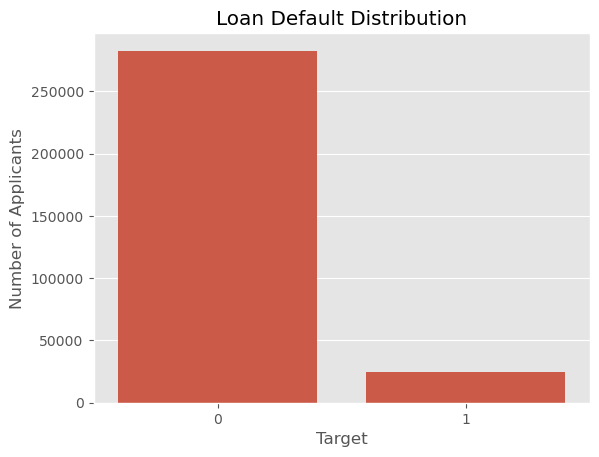

In [21]:
sns.countplot(x="TARGET", data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Applicants")

plt.show()

### Observation

The target variable is imbalanced, with a significantly higher proportion of non-default cases compared to default cases.

This class imbalance should be considered during model development and evaluation.

# Phase 4 – Data Cleaning

Data cleaning is a critical step in the Data Science workflow.

The objective of this phase is to identify and resolve data quality issues such as missing values, duplicate records, inconsistent data types, and irrelevant features while preserving as much useful information as possible.

The cleaned dataset will be used for Exploratory Data Analysis and Machine Learning.

In [24]:
# Audit Table

feature_audit=pd.DataFrame({
    "Features":df.columns,
    "Data Type":df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage":((df.isnull().sum()/len(df))*100).round(2)
    
})

feature_audit=feature_audit.sort_values(by="Missing Percentage",ascending=False)
feature_audit=feature_audit.reset_index(drop=True)
feature_audit.head(30)

,Features,Data Type,Missing Values,Missing Percentage
0,COMMONAREA_MEDI,float64,214865,69.87
1,COMMONAREA_AVG,float64,214865,69.87
2,COMMONAREA_MODE,float64,214865,69.87
3,NONLIVINGAPARTMENTS_MODE,float64,213514,69.43
4,NONLIVINGAPARTMENTS_AVG,float64,213514,69.43
5,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.43
6,FONDKAPREMONT_MODE,object,210295,68.39
7,LIVINGAPARTMENTS_MODE,float64,210199,68.35
8,LIVINGAPARTMENTS_AVG,float64,210199,68.35
9,LIVINGAPARTMENTS_MEDI,float64,210199,68.35


In [25]:
#High Missing Values

high_missing= feature_audit[feature_audit["Missing Percentage"]>60]
high_missing

,Features,Data Type,Missing Values,Missing Percentage
0,COMMONAREA_MEDI,float64,214865,69.87
1,COMMONAREA_AVG,float64,214865,69.87
2,COMMONAREA_MODE,float64,214865,69.87
3,NONLIVINGAPARTMENTS_MODE,float64,213514,69.43
4,NONLIVINGAPARTMENTS_AVG,float64,213514,69.43
5,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.43
6,FONDKAPREMONT_MODE,object,210295,68.39
7,LIVINGAPARTMENTS_MODE,float64,210199,68.35
8,LIVINGAPARTMENTS_AVG,float64,210199,68.35
9,LIVINGAPARTMENTS_MEDI,float64,210199,68.35


## Missing Value Strategy

The following strategy will be adopted during data cleaning:

- Features with less than 20% missing values will generally be imputed.
- Features with 20–60% missing values will be evaluated individually.
- Features with more than 60% missing values will be investigated before deciding whether to remove or retain them.

No feature will be removed solely based on missing percentage without understanding its business relevance.

In [27]:
high_missing=high_missing["Features"].tolist()
print("Number of high-missing features:", len(high_missing))


Number of high-missing features: 17


In [28]:
pd.crosstab(
    df["FLAG_OWN_CAR"],
    df["OWN_CAR_AGE"].isnull()
)

OWN_CAR_AGE,False,True
FLAG_OWN_CAR,,
N,0,202924
Y,104582,5


In [29]:
# drop unwanted columns

df=df.drop(columns=["SK_ID_CURR"])

In [30]:
for col in high_missing:
    print(
        col,
        "| Missing %:",
        round(df[col].isnull().mean() * 100, 2),
        "| Unique Values:",
        df[col].nunique()
    )

COMMONAREA_MEDI | Missing %: 69.87 | Unique Values: 3202
COMMONAREA_AVG | Missing %: 69.87 | Unique Values: 3181
COMMONAREA_MODE | Missing %: 69.87 | Unique Values: 3128
NONLIVINGAPARTMENTS_MODE | Missing %: 69.43 | Unique Values: 167
NONLIVINGAPARTMENTS_AVG | Missing %: 69.43 | Unique Values: 386
NONLIVINGAPARTMENTS_MEDI | Missing %: 69.43 | Unique Values: 214
FONDKAPREMONT_MODE | Missing %: 68.39 | Unique Values: 4
LIVINGAPARTMENTS_MODE | Missing %: 68.35 | Unique Values: 736
LIVINGAPARTMENTS_AVG | Missing %: 68.35 | Unique Values: 1868
LIVINGAPARTMENTS_MEDI | Missing %: 68.35 | Unique Values: 1097
FLOORSMIN_AVG | Missing %: 67.85 | Unique Values: 305
FLOORSMIN_MODE | Missing %: 67.85 | Unique Values: 25
FLOORSMIN_MEDI | Missing %: 67.85 | Unique Values: 47
YEARS_BUILD_MEDI | Missing %: 66.5 | Unique Values: 151
YEARS_BUILD_MODE | Missing %: 66.5 | Unique Values: 154
YEARS_BUILD_AVG | Missing %: 66.5 | Unique Values: 149
OWN_CAR_AGE | Missing %: 65.99 | Unique Values: 62


In [31]:
building_columns=[ "COMMONAREA_MEDI",
    "COMMONAREA_AVG",
    "COMMONAREA_MODE",
    "NONLIVINGAPARTMENTS_MODE",
    "NONLIVINGAPARTMENTS_AVG",
    "NONLIVINGAPARTMENTS_MEDI",
    "LIVINGAPARTMENTS_MODE",
    "LIVINGAPARTMENTS_AVG",
    "LIVINGAPARTMENTS_MEDI",
    "FLOORSMIN_AVG",
    "FLOORSMIN_MODE",
    "FLOORSMIN_MEDI",
    "YEARS_BUILD_MEDI",
    "YEARS_BUILD_MODE",
    "YEARS_BUILD_AVG"
]

columns_to_drop=building_columns+["FONDKAPREMONT_MODE"]
df=df.drop(columns=columns_to_drop)

In [32]:
missing=df.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
missing.head(20)

OWN_CAR_AGE           202929
LANDAREA_MEDI         182590
LANDAREA_AVG          182590
LANDAREA_MODE         182590
BASEMENTAREA_MEDI     179943
BASEMENTAREA_MODE     179943
BASEMENTAREA_AVG      179943
EXT_SOURCE_1          173378
NONLIVINGAREA_MODE    169682
NONLIVINGAREA_MEDI    169682
NONLIVINGAREA_AVG     169682
ELEVATORS_MODE        163891
ELEVATORS_MEDI        163891
ELEVATORS_AVG         163891
WALLSMATERIAL_MODE    156341
APARTMENTS_AVG        156061
APARTMENTS_MEDI       156061
APARTMENTS_MODE       156061
ENTRANCES_AVG         154828
ENTRANCES_MODE        154828
dtype: int64

In [33]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

missing_percent.head(20)

OWN_CAR_AGE           65.990810
LANDAREA_MEDI         59.376738
LANDAREA_AVG          59.376738
LANDAREA_MODE         59.376738
BASEMENTAREA_MEDI     58.515956
BASEMENTAREA_MODE     58.515956
BASEMENTAREA_AVG      58.515956
EXT_SOURCE_1          56.381073
NONLIVINGAREA_MODE    55.179164
NONLIVINGAREA_MEDI    55.179164
NONLIVINGAREA_AVG     55.179164
ELEVATORS_MODE        53.295980
ELEVATORS_MEDI        53.295980
ELEVATORS_AVG         53.295980
WALLSMATERIAL_MODE    50.840783
APARTMENTS_AVG        50.749729
APARTMENTS_MEDI       50.749729
APARTMENTS_MODE       50.749729
ENTRANCES_AVG         50.348768
ENTRANCES_MODE        50.348768
dtype: float64

In [34]:
df[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
count,3.075110e+05,3.075110e+05,307499.000000
mean,1.687979e+05,5.990260e+05,27108.573909
std,2.371231e+05,4.024908e+05,14493.737315
min,2.565000e+04,4.500000e+04,1615.500000
25%,1.125000e+05,2.700000e+05,16524.000000
50%,1.471500e+05,5.135310e+05,24903.000000
75%,2.025000e+05,8.086500e+05,34596.000000
max,1.170000e+08,4.050000e+06,258025.500000


In [35]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [36]:
print("Rows:", df.shape[0])  
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())

Rows: 307511
Columns: 105
Duplicate rows: 0
Total missing values: 5787046


In [37]:
df.select_dtypes(include="object").nunique().sort_values()

NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
CODE_GENDER                    3
HOUSETYPE_MODE                 3
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
WALLSMATERIAL_MODE             7
NAME_INCOME_TYPE               8
OCCUPATION_TYPE               18
ORGANIZATION_TYPE             58
dtype: int64

# EDA – Key Business Insights

### 1)  How common are loan defaults?

Text(0, 0.5, 'No of Applicants')

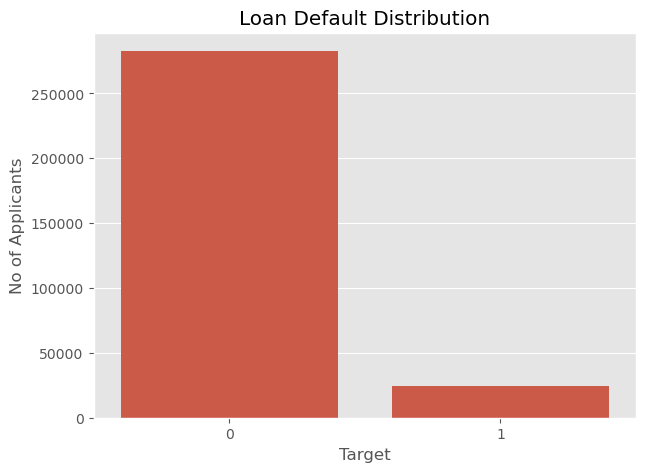

In [40]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="TARGET")

plt.title("Loan Default Distribution")
plt.xlabel("Target")
plt.ylabel("No of Applicants")

###  2) Does applicant income appear to be associated with default risk?

Text(0, 0.5, 'Annual Income')

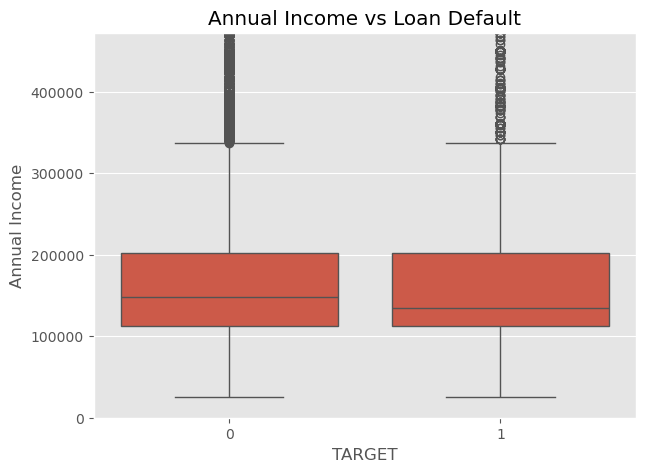

In [42]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x="TARGET",y="AMT_INCOME_TOTAL")

plt.ylim(
   0,
 df["AMT_INCOME_TOTAL"].quantile(0.99)
)

plt.title("Annual Income vs Loan Default")
plt.xlabel("TARGET")
plt.ylabel("Annual Income")

### 3) Does the requested loan amount appear to differ between defaulting and non-defaulting applicants?

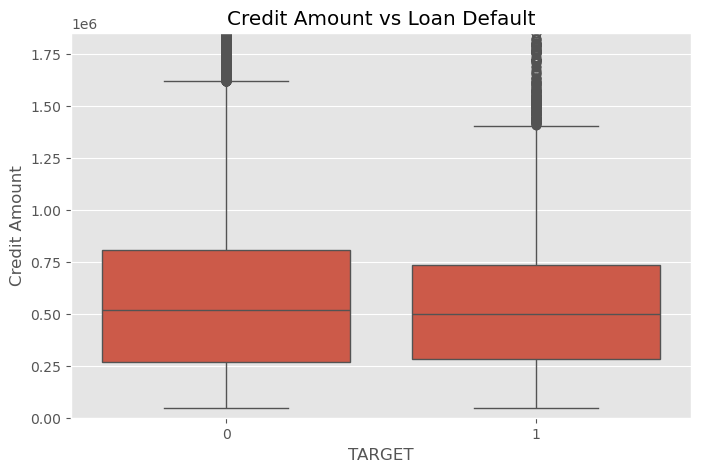

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="TARGET",y="AMT_CREDIT")
plt.ylim(0,df["AMT_CREDIT"].quantile(0.99))

plt.title("Credit Amount vs Loan Default")
plt.xlabel("TARGET")
plt.ylabel("Credit Amount")

plt.show()

- Loan amount alone is not a strong risk indicator — both groups have similar median loan amounts.
- High loan amounts are not automatically high-risk — large loans appear in both default and non-default groups.
- Assess repayment capacity, not just loan size — combine credit amount with income and credit history.
- Action: Use AMT_CREDIT as one input in the risk model, not as a standalone approval criterion.

### 4)Does the applicant's income source/type relate to default risk? (Income Type vs Default)

In [47]:
income_type=pd.crosstab(df["NAME_INCOME_TYPE"],
                       df["TARGET"],normalize="index")*100
income_type

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,100.000000,0.000000
Commercial associate,92.515743,7.484257
Maternity leave,60.000000,40.000000
Pensioner,94.613634,5.386366
State servant,94.245035,5.754965
Student,100.000000,0.000000
Unemployed,63.636364,36.363636
Working,90.411528,9.588472


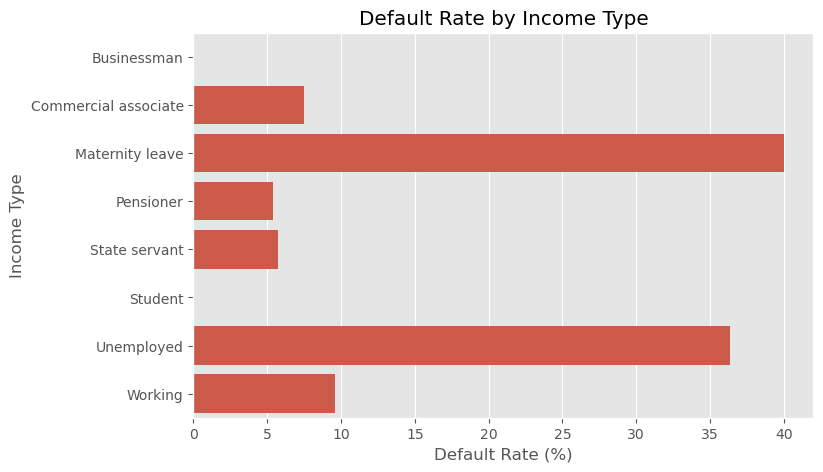

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(x=income_type[1].values,
           y=income_type.index)

plt.title("Default Rate by Income Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Income Type")

plt.show()

### Key Insights
- Maternity leave: Highest observed default rate at 40%.
- Unemployed: Very high default rate of 36.36%, indicating potential income-stability risk.
- Working: 9.59% default rate; important segment due to likely large customer volume.
- Pensioners & State servants: Relatively lower default rates of around 5–6%.
- Action: Apply enhanced credit/affordability checks for financially unstable income groups.
- Caution: Validate sample sizes before making decisions, especially for small categories.

In [50]:
df["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

### 5)Does the default rate differ across education levels?(Education vs Default)

In [52]:
education_default=pd.crosstab(df["NAME_EDUCATION_TYPE"],df["TARGET"],normalize="index")*100
education_default

# NAME_EDUCATION_TYPE represents the rows
# target represents the column


TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,98.170732,1.829268
Higher education,94.644885,5.355115
Incomplete higher,91.515034,8.484966
Lower secondary,89.072327,10.927673
Secondary / secondary special,91.060071,8.939929


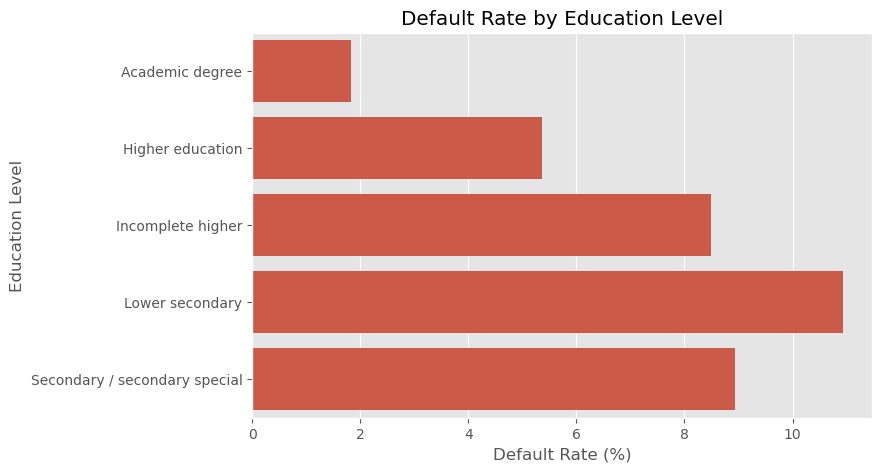

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(x=education_default[1].values,
           y=education_default.index)

plt.title("Default Rate by Education Level")
plt.xlabel("Default Rate (%)")
plt.ylabel("Education Level")
plt.show()

### 6) Age vs Default 


In [55]:
df["AGE"]=(-df["DAYS_BIRTH"]/365.25).round(1)

In [56]:
df["AGE"].describe()

count    307511.000000
mean         43.906968
std          11.947987
min          20.500000
25%          34.000000
50%          43.100000
75%          53.900000
max          69.100000
Name: AGE, dtype: float64

In [57]:
# Creating Age Groups

df["Age_Groups"]=pd.cut(df["AGE"],bins=[18,25,35,45,55,70,100],
                        labels=["18-25","26-35","36-45","46-55","56-70","70+"],
                       include_lowest=True)


In [58]:
age_default=pd.crosstab(df["Age_Groups"],df["TARGET"],normalize="index")*100
age_default

TARGET,0,1
Age_Groups,,
18-25,87.729321,12.270679
26-35,89.343709,10.656291
36-45,91.600472,8.399528
46-55,92.964503,7.035497
56-70,94.778993,5.221007


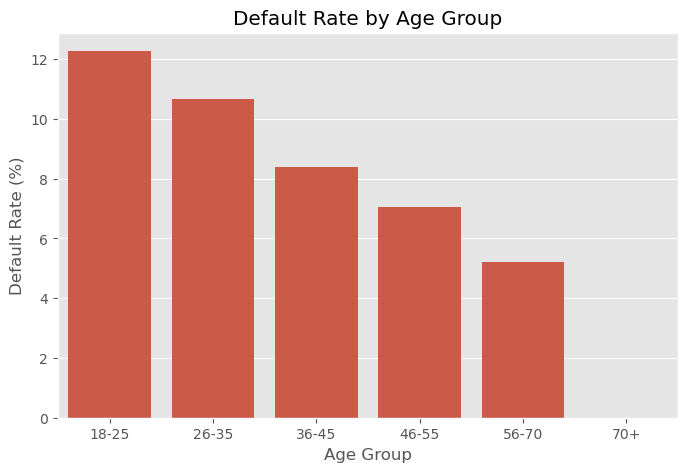

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(x=age_default.index,
           y=age_default[1].values)


plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

plt.show()

Insights:

- Young borrowers (18–25) show the highest default rate at ~12.3%.
- Action: Apply enhanced affordability/credit checks for younger borrowers.
- Strategy: Use age as a risk-segmentation factor, but combine it with income, credit amount, and credit history before making lending decisions.

### 7) Employment Duration vs Default

In [62]:
df["EMPLOYMENT_YEARS"] = (-df["DAYS_EMPLOYED"] / 365.25)

In [63]:
df["EMPLOYMENT_YEARS"].describe()

count    307511.000000
mean       -174.716074
std         386.791969
min        -999.980835
25%           0.791239
50%           3.321013
75%           7.556468
max          49.040383
Name: EMPLOYMENT_YEARS, dtype: float64

### 8) Credit-to-Income Ratio

In [65]:
df["Credit_Income_Ratio"]=(df["AMT_CREDIT"]/df["AMT_INCOME_TOTAL"])


In [66]:
df["Credit_Income_Ratio"].describe()

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: Credit_Income_Ratio, dtype: float64

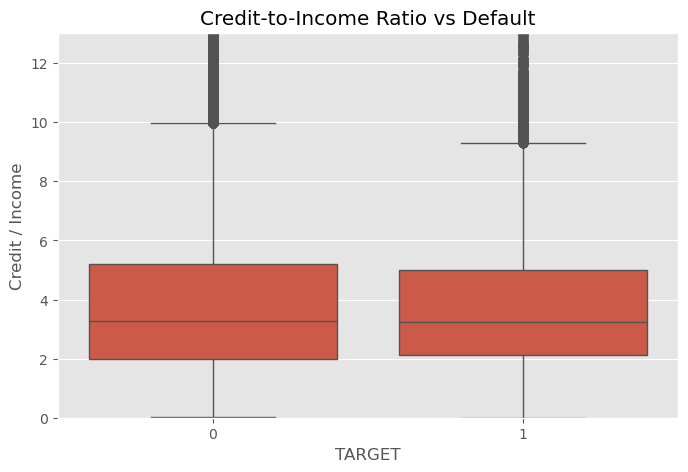

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="TARGET",
    y="Credit_Income_Ratio")

plt.ylim( 0, df["Credit_Income_Ratio"].quantile(0.99))

plt.title("Credit-to-Income Ratio vs Default")
plt.xlabel("TARGET")
plt.ylabel("Credit / Income")

plt.show()

- Credit-to-income ratios are broadly similar across defaulters and non-defaulters, suggesting limited standalone predictive power for default risk.

### 9) External Credit Scores

In [70]:
external_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

df[external_features + ["TARGET"]].corr()["TARGET"].sort_values()

EXT_SOURCE_3   -0.178919
EXT_SOURCE_2   -0.160472
EXT_SOURCE_1   -0.155317
TARGET          1.000000
Name: TARGET, dtype: float64

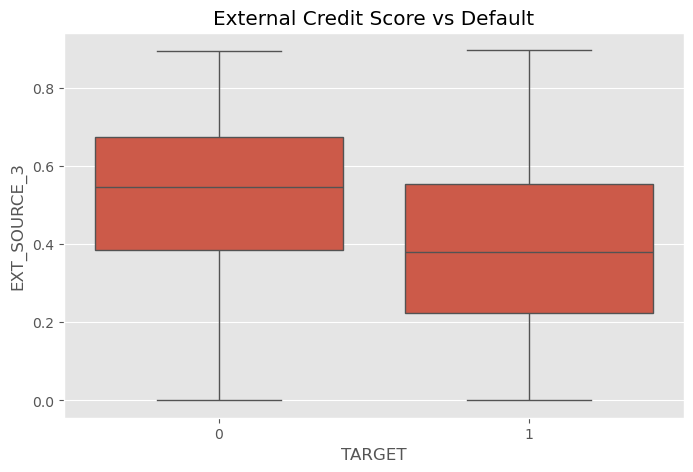

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="TARGET",
    y="EXT_SOURCE_3"
)

plt.title("External Credit Score vs Default")
plt.xlabel("TARGET")
plt.ylabel("EXT_SOURCE_3")

plt.show()

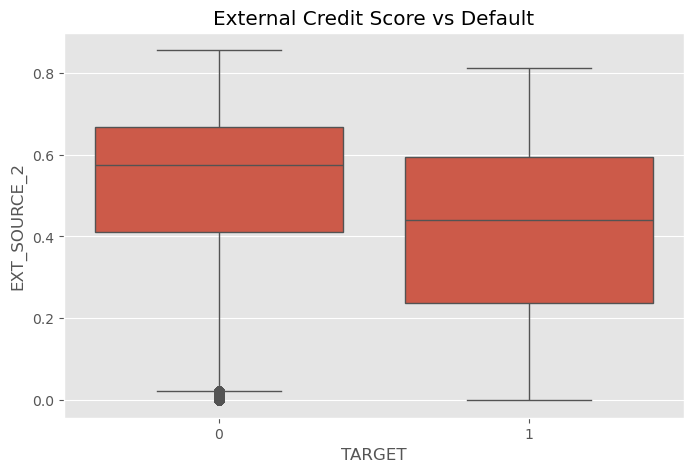

In [72]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="TARGET",
    y="EXT_SOURCE_2"
)

plt.title("External Credit Score vs Default")
plt.xlabel("TARGET")
plt.ylabel("EXT_SOURCE_2")

plt.show()

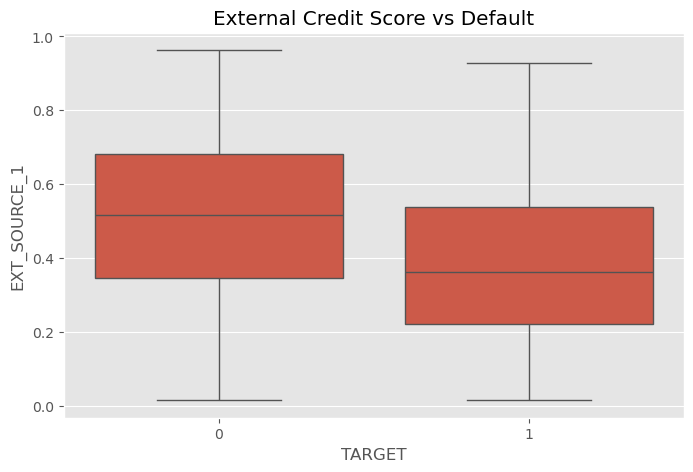

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="TARGET",
    y="EXT_SOURCE_1"
)

plt.title("External Credit Score vs Default")
plt.xlabel("TARGET")
plt.ylabel("EXT_SOURCE_1")

plt.show()

In [74]:
financial_features = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

correlation = df[financial_features].corr()

correlation["TARGET"].sort_values()

EXT_SOURCE_3       -0.178919
EXT_SOURCE_2       -0.160472
EXT_SOURCE_1       -0.155317
DAYS_EMPLOYED      -0.044932
AMT_GOODS_PRICE    -0.039645
AMT_CREDIT         -0.030369
AMT_ANNUITY        -0.012817
AMT_INCOME_TOTAL   -0.003982
DAYS_BIRTH          0.078239
TARGET              1.000000
Name: TARGET, dtype: float64

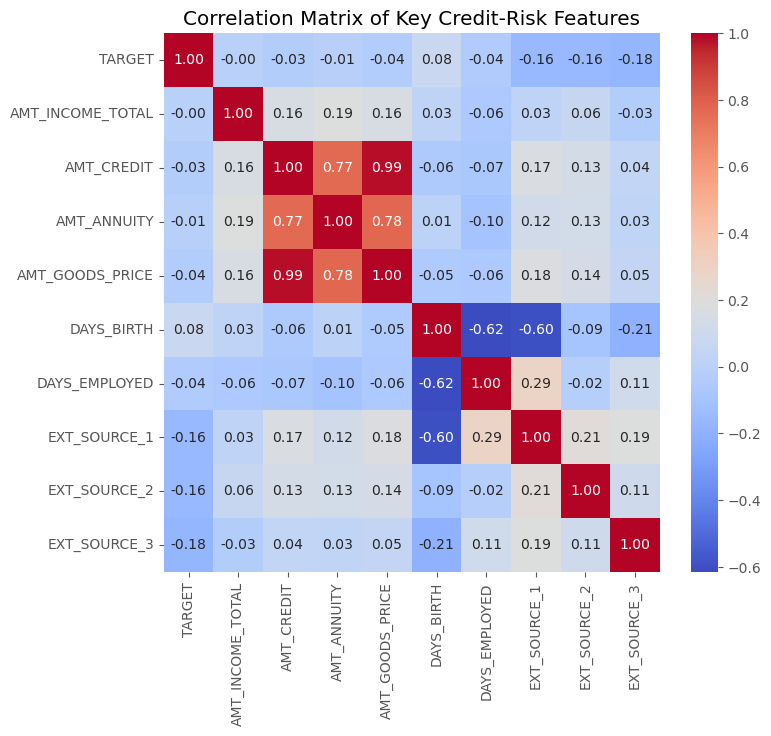

In [75]:
plt.figure(figsize=(8,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Key Credit-Risk Features")

plt.show()

### Key Insights

- External credit scores are the strongest risk indicators, especially EXT_SOURCE_3.
- Higher external scores → lower observed default risk.
- Income and loan amount show weak direct relationships with default.
- Age has limited standalone predictive power.
- AMT_CREDIT and AMT_GOODS_PRICE are highly redundant (0.99 correlation).
- Action: Use a multi-factor risk model, prioritizing external credit indicators rather than relying on a single variable.

# EDA – Key Business Insights

### 1. Default Risk
The dataset is highly imbalanced, with non-default applicants representing the majority of observations. Therefore, identifying the smaller high-risk population is particularly important.

### 2. Income
Income provides information about an applicant's potential repayment capacity. Differences in income distributions between default groups will be considered during feature engineering.

### 3. Loan Amount
Loan amount alone does not fully represent borrowing burden. It should be evaluated relative to applicant income.

### 4. Income Type
Default rates differ across income-source categories, indicating that employment/income characteristics may contain useful risk information.

### 5. Age
Default rates vary across age groups, suggesting that applicant age may provide additional predictive information.

### 6. Credit-to-Income Ratio
The relationship between requested credit and applicant income provides a more meaningful measure of borrowing burden than loan amount alone. This will be considered as an engineered feature.

### 7. External Credit Scores
External credit-related variables show potentially strong relationships with default and will be important candidates for the predictive model.

### 8. Modeling Implication
The EDA indicates that credit risk is influenced by multiple dimensions, including financial capacity, loan burden, demographic characteristics, employment characteristics, and external credit information. These relationships will be explored further through feature engineering and machine learning.

# Phase 6 – Feature Engineering

Feature engineering transforms raw variables into meaningful features that better represent applicant characteristics, financial burden, repayment capacity, and credit risk.

The features created in this phase are driven by the findings from exploratory data analysis and the business requirements of a credit-risk assessment system.

In [79]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [80]:
df["DAYS_EMPLOYED"].sort_values(ascending=False).head(10)

146327    365243
229266    365243
157475    365243
229294    365243
157480    365243
80598     365243
229285    365243
80597     365243
157481    365243
229277    365243
Name: DAYS_EMPLOYED, dtype: int64

In [81]:
df["DAYS_EMPLOYED"]=df["DAYS_EMPLOYED"].replace(365243,np.nan)

In [82]:
df["DAYS_EMPLOYED"].sort_values(ascending=False).head(10)

121625    0.0
23691     0.0
246105   -1.0
111965   -2.0
161893   -2.0
239303   -3.0
239079   -3.0
247112   -3.0
17355    -4.0
19381    -4.0
Name: DAYS_EMPLOYED, dtype: float64

In [83]:
df["EMPLOYEMENT_YEARS"]=(-df["DAYS_EMPLOYED"]/365.25).round(1)
df["EMPLOYMENT_YEARS"].describe()

count    307511.000000
mean       -174.716074
std         386.791969
min        -999.980835
25%           0.791239
50%           3.321013
75%           7.556468
max          49.040383
Name: EMPLOYMENT_YEARS, dtype: float64

In [84]:
df["EMPLOYEMENT_YEARS"].head(10)

0    1.7
1    3.3
2    0.6
3    8.3
4    8.3
5    4.3
6    8.6
7    1.2
8    NaN
9    5.5
Name: EMPLOYEMENT_YEARS, dtype: float64

In [85]:
# AMT_ANNUITY represents the loan's annuity/payment obligation.

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

In [86]:
df["ANNUITY_INCOME_RATIO"].describe()

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: ANNUITY_INCOME_RATIO, dtype: float64

#### Create Credit-to-Goods Ratio

In [88]:
df["CREDIT_GOODS_RATIO"] = (df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"])

In [89]:
df["CREDIT_GOODS_RATIO"].describe()

count    307233.000000
mean          1.122995
std           0.124045
min           0.150000
25%           1.000000
50%           1.118800
75%           1.198000
max           6.000000
Name: CREDIT_GOODS_RATIO, dtype: float64

In [90]:
external_cols=[ "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"]

# Instead of treating them completely independently, create a combined score.

In [91]:
df["EXT_SOURCE_MEAN"]=df[external_cols].mean(axis=1)

In [92]:
df["EXT_SOURCE_MIN"]=df[external_cols].min(axis=1)

In [93]:
df["EXT_SOURCE_MAX"]=df[external_cols].max(axis=1)

#### Creating Employment Stability Groups

In [95]:
# Employment Stability Groups

df["EMPLOYMENT_GROUP"]=pd.cut(df["EMPLOYEMENT_YEARS"],
                               bins=[-1,2,5,10,20,np.inf],
                               labels=["<2 Years", "2-5 Years","5-10 Years","10-20 Years","20+ Years"])

In [96]:
df["EMPLOYMENT_GROUP"].value_counts().sort_index()

EMPLOYMENT_GROUP
<2 Years       61477
2-5 Years      75838
5-10 Years     64301
10-20 Years    38101
20+ Years      12420
Name: count, dtype: int64

#### Creating a Family Burden Feature

In [98]:
# Features present- CNT_CHILDREN ,CNT_FAM_MEMBERS

df["DEPENDENTS"]=( df["CNT_FAM_MEMBERS"]-1)

# This can provide a proxy for household financial responsibility.

#### Creating Loan-to-Annuity relationship

In [100]:
df["CREDIT_ANNUITY_RATIO"]=( df["AMT_CREDIT"] / df["AMT_ANNUITY"])

#### Validating all engineered features

In [102]:
engineered_features=["AGE",
    "EMPLOYMENT_YEARS",
    "Credit_Income_Ratio",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX",
    "DEPENDENTS",
    "CREDIT_ANNUITY_RATIO"  
]

In [103]:
df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
AGE,307511.0,43.906968,11.947987,2.050000e+01,34.000000,43.100000,53.900000,69.100000
EMPLOYMENT_YEARS,307511.0,-174.716074,386.791969,-9.999808e+02,0.791239,3.321013,7.556468,49.040383
Credit_Income_Ratio,307511.0,3.957570,2.689728,4.807615e-03,2.018667,3.265067,5.159880,84.736842
ANNUITY_INCOME_RATIO,307499.0,0.180930,0.094574,2.238846e-04,0.114782,0.162833,0.229067,1.875965
CREDIT_GOODS_RATIO,307233.0,1.122995,0.124045,1.500000e-01,1.000000,1.118800,1.198000,6.000000
EXT_SOURCE_MEAN,307339.0,0.509251,0.149802,5.940000e-06,0.413648,0.524502,0.622819,0.878903
EXT_SOURCE_MIN,307339.0,0.399582,0.187425,8.170000e-08,0.253963,0.403167,0.553013,0.878903
EXT_SOURCE_MAX,307339.0,0.615882,0.156130,5.940000e-06,0.540654,0.648470,0.725276,0.962693
DEPENDENTS,307509.0,1.152665,0.910682,0.000000e+00,1.000000,1.000000,2.000000,19.000000
CREDIT_ANNUITY_RATIO,307499.0,21.612322,7.823823,8.036674e+00,15.614496,20.000000,27.099985,45.305079


In [104]:
df[engineered_features].isnull().sum()

AGE                       0
EMPLOYMENT_YEARS          0
Credit_Income_Ratio       0
ANNUITY_INCOME_RATIO     12
CREDIT_GOODS_RATIO      278
EXT_SOURCE_MEAN         172
EXT_SOURCE_MIN          172
EXT_SOURCE_MAX          172
DEPENDENTS                2
CREDIT_ANNUITY_RATIO     12
dtype: int64

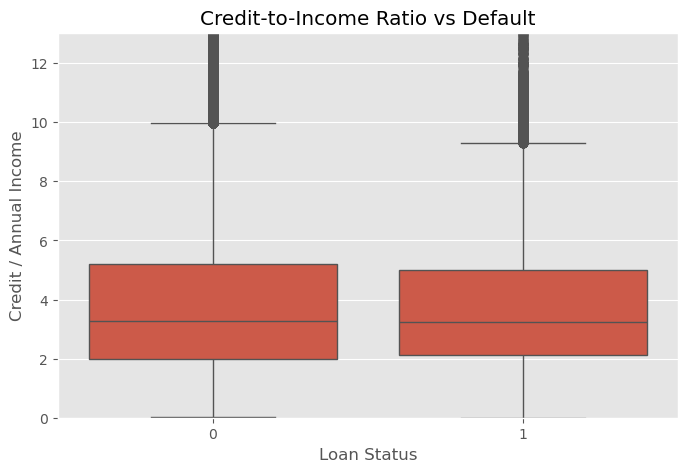

In [105]:
# Credit-to-income vs default

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="TARGET",
           y="Credit_Income_Ratio")

plt.ylim(
    0,
    df["Credit_Income_Ratio"].quantile(0.99)
)

plt.title("Credit-to-Income Ratio vs Default")
plt.xlabel("Loan Status")
plt.ylabel("Credit / Annual Income")

plt.show()

- Similar medians for defaulters and non-defaulters.
- High overlap between both groups.
- Many high-value outliers are present.
- Weak standalone predictor of default.

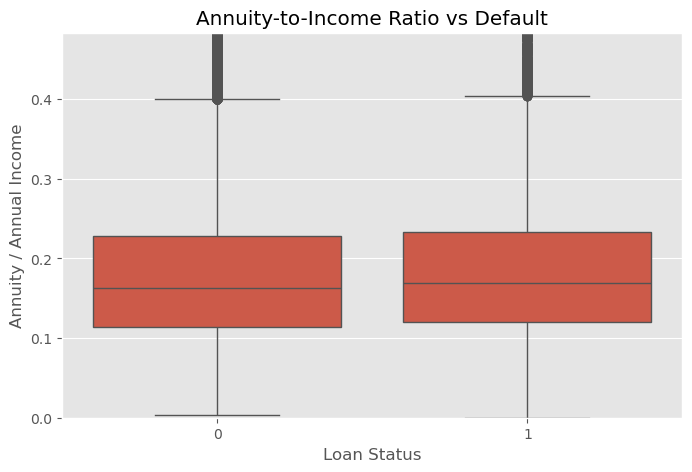

In [107]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="TARGET",
    y="ANNUITY_INCOME_RATIO"
)

plt.ylim(
    0,
    df["ANNUITY_INCOME_RATIO"].quantile(0.99)
)

plt.title("Annuity-to-Income Ratio vs Default")
plt.xlabel("Loan Status")
plt.ylabel("Annuity / Annual Income")

plt.show()

- Similar medians for both groups (~0.16–0.17).
- High overlap between defaulters and non-defaulters.
- Many high-value outliers above ~0.40.
- Weak standalone predictor of default.

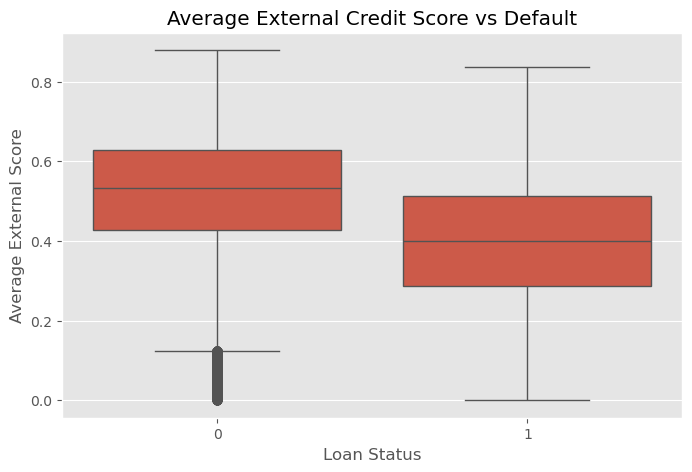

In [109]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="TARGET",
    y="EXT_SOURCE_MEAN"
)

plt.title("Average External Credit Score vs Default")
plt.xlabel("Loan Status")
plt.ylabel("Average External Score")

plt.show()

- **Lower credit scores among defaulters** (median ~0.40 vs ~0.53).
- **Clearer separation** between default and non-default groups.
- **Low external credit score may indicate higher default risk.**
- **Strong potential predictor** of default.

In [111]:
print("Dataset Shape:", df.shape)

print(
    "Number of Engineered Features:",
    len(engineered_features)
)

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Dataset Shape: (307511, 118)
Number of Engineered Features: 10
Total Missing Values: 5953988
Duplicate Rows: 0


# Phase 7 – Data Preprocessing

## Objective

The objective of this phase is to prepare the engineered dataset for machine learning while preventing data leakage.

The dataset contains numerical and categorical variables, missing values, and features with different scales. Machine learning algorithms require these variables to be converted into a suitable numerical format.

PROCEDURE:

1. X and y separation
        
2. Train-test split
        
3. Identify numerical/categorical columns
        
4. Numerical preprocessing pipeline
        
5. Categorical preprocessing pipeline
        
6. Combine using ColumnTransformer
        
7. Fit on X_train
        
8. Transform X_test
        
9. Validate processed data

In [114]:
X=df.drop(columns=["TARGET"])
Y=df["TARGET"]

In [115]:
print("X Shape:",X.shape)
print("Y Shape:",Y.shape)

X Shape: (307511, 117)
Y Shape: (307511,)


#### Train-Test Split

In [117]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [118]:
print("Training target distribution:")
print(Y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(Y_test.value_counts(normalize=True))

Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Testing target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


#### Identifying Numerical and Categorical Features

In [120]:
numerical_features=X_train.select_dtypes(include=["int64","float64"]).columns.tolist()

categorical_features=X_train.select_dtypes(include=["object","category"]).columns.tolist()

In [121]:
print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 100
Number of categorical features: 17


- 1)Numerical
    
- 2)Missing values → Median
    
- 3)Scaling

- 1)Categorical
    
- 2)Missing values → Most frequent
    
- 3)One-Hot Encoding

In [123]:
# Import Preprocessing Tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [124]:
# Numerical Preprocessing Pipeline

numerical_pipeline=Pipeline([("imputer",SimpleImputer(strategy="median")),
                             ("scaler", StandardScaler())
    
])

# This pipeline takes numerical features, fills missing values using the median, then standardizes them 
#so they're ready to be safely used by a machine-learning model.

In [125]:
# Categorical Preprocessing Pipeline

categorical_pipeline=Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),
                               ("encoder",OneHotEncoder(handle_unknown="ignore",
                                                        sparse_output=False))
    
])

#### Combining Both Pipelines

In [127]:
preprocessor= ColumnTransformer(
    transformers=[
        ("num",numerical_pipeline,numerical_features),
        ("cat",categorical_pipeline,categorical_features)
    ]
)

#### Fitting the Preprocessor on Training Data

In [129]:
X_train_processed=preprocessor.fit_transform(X_train)

In [130]:
X_test_processed=preprocessor.transform(X_test)

In [131]:
print("Original X shape:", X.shape)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X shape: (307511, 117)
X_train shape: (246008, 117)
X_test shape: (61503, 117)
Processed X_train shape: (246008, 246)
Processed X_test shape: (61503, 246)


##### Checking for Remaining Missing Values

In [133]:
print(
    "Missing values in X_train:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing values in X_test:",
    np.isnan(X_test_processed).sum()
)

Missing values in X_train: 0
Missing values in X_test: 0


#### Save Processed Feature Names

In [135]:
feature_names=preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

Number of processed features: 246


In [136]:
feature_names[:20]

array(['num__CNT_CHILDREN', 'num__AMT_INCOME_TOTAL', 'num__AMT_CREDIT',
       'num__AMT_ANNUITY', 'num__AMT_GOODS_PRICE',
       'num__REGION_POPULATION_RELATIVE', 'num__DAYS_BIRTH',
       'num__DAYS_EMPLOYED', 'num__DAYS_REGISTRATION',
       'num__DAYS_ID_PUBLISH', 'num__OWN_CAR_AGE', 'num__FLAG_MOBIL',
       'num__FLAG_EMP_PHONE', 'num__FLAG_WORK_PHONE',
       'num__FLAG_CONT_MOBILE', 'num__FLAG_PHONE', 'num__FLAG_EMAIL',
       'num__CNT_FAM_MEMBERS', 'num__REGION_RATING_CLIENT',
       'num__REGION_RATING_CLIENT_W_CITY'], dtype=object)

In [137]:
print("Training Target:")
print(Y_train.value_counts())

print("\nTesting Target:")
print(Y_test.value_counts())

Training Target:
TARGET
0    226148
1     19860
Name: count, dtype: int64

Testing Target:
TARGET
0    56538
1     4965
Name: count, dtype: int64


In [138]:
print("Training Target %:")
print(Y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting Target %:")
print(Y_test.value_counts(normalize=True).mul(100).round(2))

Training Target %:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

Testing Target %:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [139]:
print("========== PHASE 7 VALIDATION ==========")

print("Original dataset:", df.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Processed X_train:", X_train_processed.shape)
print("Processed X_test:", X_test_processed.shape)

print(
    "\nMissing values in processed X_train:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing values in processed X_test:",
    np.isnan(X_test_processed).sum()
)

print(
    "\nDuplicate rows in original dataset:",
    df.duplicated().sum()
)

print("========================================")

========== PHASE 7 VALIDATION ==========
Original dataset: (307511, 118)
X_train: (246008, 117)
X_test: (61503, 117)
Processed X_train: (246008, 246)
Processed X_test: (61503, 246)

Missing values in processed X_train: 0
Missing values in processed X_test: 0

Duplicate rows in original dataset: 0


# Phase 8 – Model Development

## Objective

The objective of this phase is to develop machine learning models that can predict whether a loan applicant is likely to default.

Since the target variable is binary:

- 0 → No Default
- 1 → Default

this is a binary classification problem.

Multiple machine learning models will be developed and compared to determine which model provides the most effective balance between identifying risky applicants and minimizing incorrect predictions.

Because the target variable is highly imbalanced, model performance will not be evaluated using accuracy alone. Precision, Recall, F1-score, ROC-AUC and other relevant classification metrics will be considered.

## Class Imbalance

The target variable is highly imbalanced, with substantially more non-default applications than default applications.

This creates a problem because a model could achieve high accuracy by predicting the majority class most of the time while failing to identify applicants who are actually at risk of default.

Therefore, class imbalance will be considered during model development and model evaluation.

In [142]:
print("Training Target Distributiom:")
print(Y_train.value_counts())

print("\nTraining Target Percentage:")
print(Y_train.value_counts(normalize=True).mul(100).round(2))

Training Target Distributiom:
TARGET
0    226148
1     19860
Name: count, dtype: int64

Training Target Percentage:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


## Model Evaluation Metrics

### Accuracy
Measures the overall percentage of correct predictions.

### Precision
Of the applicants predicted as high-risk, how many actually defaulted?

### Recall
Of the applicants who actually defaulted, how many did the model identify?

### F1-Score
Balances Precision and Recall.

### ROC-AUC
Measures the model's ability to distinguish between defaulting and non-defaulting applicants across different classification thresholds.

### Model 1 — Basic Logistic Regression

In [145]:
from sklearn.linear_model import LogisticRegression

In [146]:
logistic_model=LogisticRegression(max_iter=1000,
                                 random_state=42)

In [147]:
#Train
logistic_model.fit(X_train_processed,Y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [148]:
#Predict
Y_logistic_pred=logistic_model.predict(X_test_processed)

In [149]:
Y_logistic_prob=logistic_model.predict_proba(X_test_processed)[:,1]

In [150]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score,roc_auc_score)

In [151]:
print("Logistic Regression Performance")

print(
    "Accuracy:",
    accuracy_score(Y_test, Y_logistic_pred)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        Y_logistic_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        Y_logistic_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        Y_test,
        Y_logistic_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        Y_test,
        Y_logistic_prob
    )
)

Logistic Regression Performance
Accuracy: 0.9196299367510528
Precision: 0.6057692307692307
Recall: 0.012688821752265862
F1 Score: 0.02485697376208325
ROC-AUC: 0.750563306761181


In [152]:
from sklearn.metrics import classification_report

print(
    classification_report(
        Y_test,
        Y_logistic_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.61      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.76      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



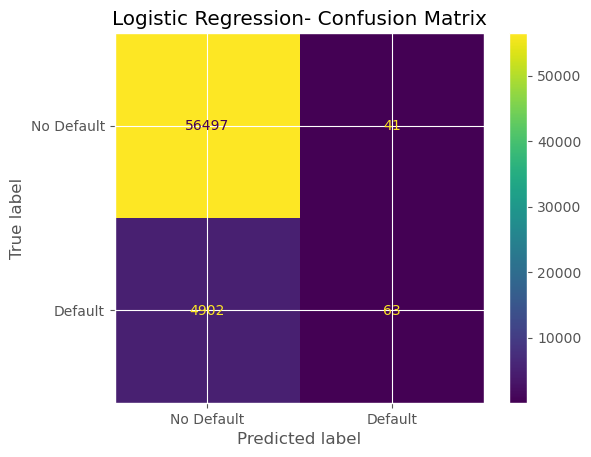

In [153]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm=confusion_matrix(Y_test,Y_logistic_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=[
                                "No Default",
                                "Default"
                            ]
    
)

disp.plot()
plt.title("Logistic Regression- Confusion Matrix")
plt.show()

## Handling Class Imbalance

The baseline Logistic Regression model achieved a high number of correct predictions for non-default applicants but failed to identify most defaulting applicants.

This is primarily due to the strong class imbalance in the target variable.

To address this, a class-weighted Logistic Regression model will be trained. The `class_weight="balanced"` parameter automatically assigns greater importance to the minority default class during model training.

In [155]:
balanced_logistic=LogisticRegression(max_iter=1000,
                                    class_weight="balanced",
                                    random_state=42)
balanced_logistic.fit(
    X_train_processed,Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [156]:
# PREDICTION

Y_balanced_pred=balanced_logistic.predict(X_test_processed)

Y_balanced_prob=balanced_logistic.predict_proba(X_test_processed)[:,1]

In [157]:
print("Balanced Logistic Regression Performance")

print(
    "Accuracy:",
    accuracy_score(Y_test, Y_balanced_pred)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        Y_balanced_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        Y_balanced_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        Y_test,
        Y_balanced_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        Y_test,
        Y_balanced_prob
    )
)

Balanced Logistic Regression Performance
Accuracy: 0.6896248963465197
Precision: 0.16051341217190654
Recall: 0.6725075528700907
F1 Score: 0.2591687041564792
ROC-AUC: 0.7504618572891133


In [158]:
print(
    classification_report(
        Y_test,
        Y_balanced_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.96      0.69      0.80     56538
     Default       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



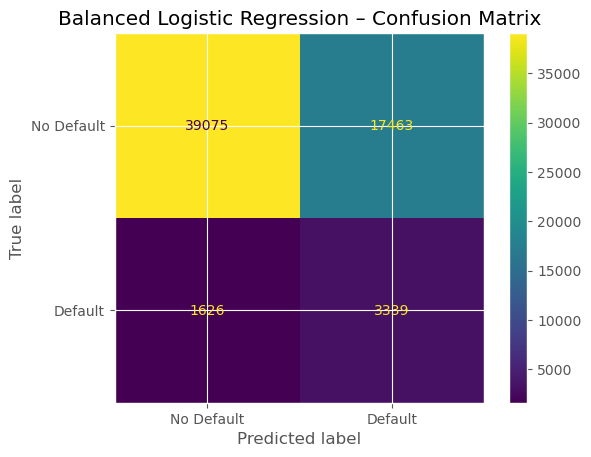

In [159]:
cm_balanced = confusion_matrix(
    Y_test,
    Y_balanced_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=[
        "No Default",
        "Default"
    ]
)

disp.plot()

plt.title(
    "Balanced Logistic Regression – Confusion Matrix"
)

plt.show()

## Balanced Logistic Regression – Business Interpretation

Class weighting substantially improved the model's ability to identify defaulting applicants.

The model achieved a recall of approximately 67%, meaning it identified around two-thirds of actual defaulters. 

Therefore, the balanced Logistic Regression model is a significant improvement over the baseline model for detecting risky applicants, but it is not yet suitable as the final credit-risk model. 

## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction stability and reduce overfitting.

It is particularly useful for this credit-risk problem because it can capture non-linear relationships and interactions between applicant characteristics that may not be captured by Logistic Regression.

In [162]:
from sklearn.ensemble import RandomForestClassifier

In [163]:
random_forest=RandomForestClassifier(
    n_estimators=200,    # 200 decision tress
    random_state=42,
    n_jobs=-1
)

In [164]:
random_forest.fit(X_train_processed,Y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [165]:
Y_rf_pred=random_forest.predict(X_test_processed)

In [166]:
Y_rf_prob=random_forest.predict_proba(X_test_processed)[:,1]

In [167]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Random Forest Performance")

print(
    "Accuracy:",
    accuracy_score(Y_test, Y_rf_pred)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        Y_rf_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        Y_rf_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        Y_test,
        Y_rf_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        Y_test,
        Y_rf_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        Y_test,
        Y_rf_prob
    )
)

Random Forest Performance
Accuracy: 0.9194836024258979
Precision: 0.696969696969697
Recall: 0.004632426988922457
F1 Score: 0.009203681472589036
ROC-AUC: 0.7303807272792174
PR-AUC: 0.22605477692316037


In [168]:
print(
    classification_report(
        Y_test,
        Y_rf_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.70      0.00      0.01      4965

    accuracy                           0.92     61503
   macro avg       0.81      0.50      0.48     61503
weighted avg       0.90      0.92      0.88     61503



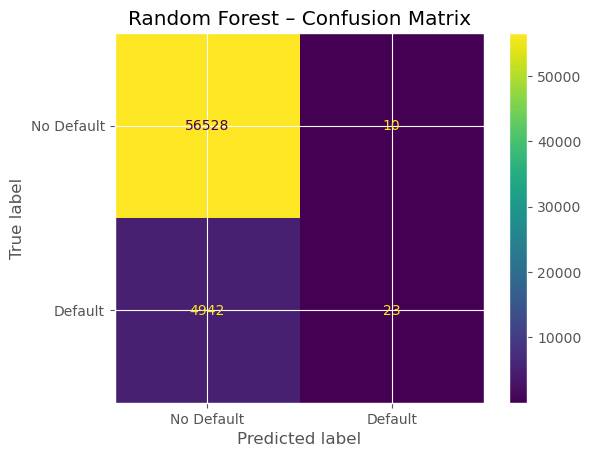

In [169]:
cm_rf = confusion_matrix(
    Y_test,
    Y_rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "No Default",
        "Default"
    ]
)

disp.plot()

plt.title("Random Forest – Confusion Matrix")
plt.show()

## Balanced Random Forest

The baseline Random Forest strongly favored the majority class and achieved a recall of only 0.46% for defaulting applicants.

To address this class imbalance, a class-weighted Random Forest will be trained. The `class_weight="balanced"` parameter increases the importance of the minority default class during model training.

The objective is to improve the model's ability to identify potential defaulters while maintaining an acceptable level of precision.

In [171]:
balanced_rf=RandomForestClassifier(n_estimators=200,class_weight="balanced",random_state=42,n_jobs=-1)

In [172]:
balanced_rf.fit(X_train_processed,Y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [173]:
Y_balanced_rf_pred=balanced_rf.predict(X_test_processed)

In [174]:
Y_balanced_rf_prob = balanced_rf.predict_proba(
    X_test_processed
)[:, 1]

In [175]:
print("Balanced Random Forest Performance")

print("Accuracy:",
      accuracy_score(Y_test, Y_balanced_rf_pred))

print("Precision:",
      precision_score(Y_test, Y_balanced_rf_pred, zero_division=0))

print("Recall:",
      recall_score(Y_test, Y_balanced_rf_pred, zero_division=0))

print("F1 Score:",
      f1_score(Y_test, Y_balanced_rf_pred, zero_division=0))

print("ROC-AUC:",
      roc_auc_score(Y_test, Y_balanced_rf_prob))

print("PR-AUC:",
      average_precision_score(Y_test, Y_balanced_rf_prob))

Balanced Random Forest Performance
Accuracy: 0.9192884899923581
Precision: 0.5074626865671642
Recall: 0.006847935548841893
F1 Score: 0.013513513513513514
ROC-AUC: 0.7420791360030311
PR-AUC: 0.22160548329703914


In [176]:
print(
    classification_report(
        Y_test,
        Y_balanced_rf_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.51      0.01      0.01      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.50      0.49     61503
weighted avg       0.89      0.92      0.88     61503



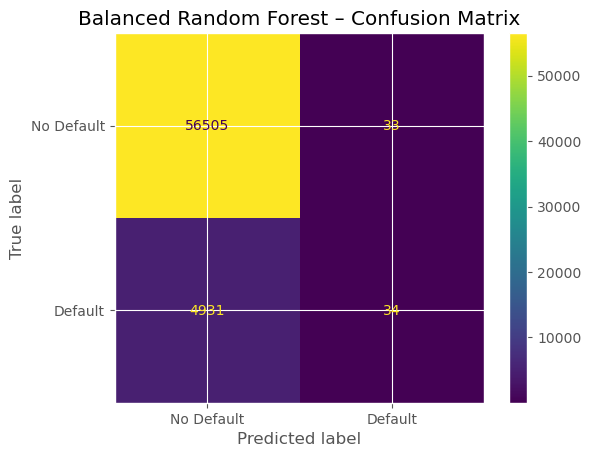

In [177]:
cm_balanced_rf = confusion_matrix(
    Y_test,
    Y_balanced_rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced_rf,
    display_labels=[
        "No Default",
        "Default"
    ]
)

disp.plot()

plt.title("Balanced Random Forest – Confusion Matrix")
plt.show()

Random Forest produces very few false alarms, but it misses almost all actual defaulters. Therefore, it is not suitable for the current credit-risk objective without further optimization.

## XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble machine learning algorithm based on decision trees.

Unlike Random Forest, where many trees are built independently and their predictions are combined, XGBoost builds trees sequentially.

Each new tree focuses on correcting the errors made by the previous trees.

This allows XGBoost to learn complex non-linear relationships and interactions between features and is particularly effective for structured/tabular datasets.

In [180]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [181]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


## Baseline XGBoost

A baseline XGBoost model is trained first without explicit class balancing.

This provides a reference point for evaluating the effect of handling the class imbalance in later experiments.

In [183]:
from xgboost import XGBClassifier

In [184]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist"
)

In [185]:
xgb_model.fit(X_train_processed,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [186]:
Y_xgb_pred = xgb_model.predict(
    X_test_processed
)

In [187]:
Y_xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [188]:
print("XGBoost Performance")

print(
    "Accuracy:",
    accuracy_score(Y_test, Y_xgb_pred)
)

print(
    "Precision:",
    precision_score(
        Y_test,
        Y_xgb_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        Y_xgb_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        Y_test,
        Y_xgb_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        Y_test,
        Y_xgb_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        Y_test,
        Y_xgb_prob
    )
)

XGBoost Performance
Accuracy: 0.9198087898151309
Precision: 0.6204379562043796
Recall: 0.017119838872104734
F1 Score: 0.033320266562132494
ROC-AUC: 0.7649957267464633
PR-AUC: 0.2577256642256786


In [189]:
print(
    classification_report(
        Y_test,
        Y_xgb_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.62      0.02      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.77      0.51      0.50     61503
weighted avg       0.90      0.92      0.88     61503



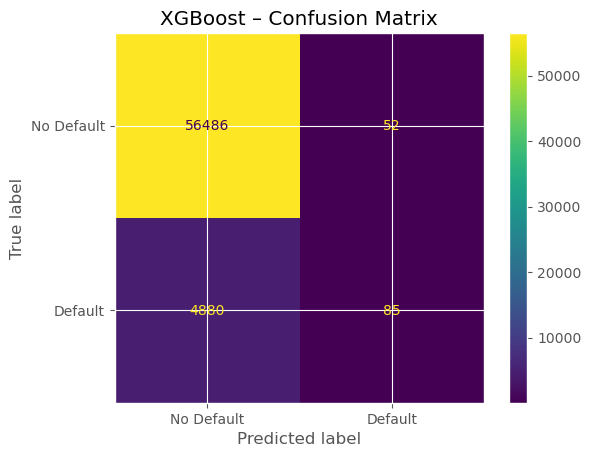

In [190]:
cm_xgb = confusion_matrix(
    Y_test,
    Y_xgb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=[
        "No Default",
        "Default"
    ]
)

disp.plot()

plt.title("XGBoost – Confusion Matrix")

plt.show()

- XGBoost appears to rank applicants by risk better than Random Forest, but its default classification threshold is too conservative for identifying the minority default class.
- XGBoost is behaving better than both Random Forest versions in terms of discrimination, but its default 0.5 threshold is still producing very poor recall.

In [192]:
scale_pos_weight = (
    (Y_train == 0).sum() /
    (Y_train == 1).sum()
)

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 11.38710976837865


In [193]:
balanced_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist"
)

In [194]:
balanced_xgb.fit(
    X_train_processed,
    Y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [195]:
Y_balanced_xgb_pred = balanced_xgb.predict(X_test_processed)

In [196]:
Y_balanced_xgb_prob = balanced_xgb.predict_proba(X_test_processed)[:, 1]

In [197]:
print("Balanced XGBoost Performance")

print(
    "Accuracy:",
    accuracy_score(
        Y_test,
        Y_balanced_xgb_pred
    )
)

print(
    "Precision:",
    precision_score(
        Y_test,
        Y_balanced_xgb_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        Y_balanced_xgb_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        Y_test,
        Y_balanced_xgb_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        Y_test,
        Y_balanced_xgb_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        Y_test,
        Y_balanced_xgb_prob
    )
)

Balanced XGBoost Performance
Accuracy: 0.7124205323317562
Precision: 0.17305715460526316
Recall: 0.678147029204431
F1 Score: 0.27574628393595674
ROC-AUC: 0.7648458271183153
PR-AUC: 0.2554814332470883


In [198]:
print(
    classification_report(
        Y_test,
        Y_balanced_xgb_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.96      0.72      0.82     56538
     Default       0.17      0.68      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.71      0.78     61503



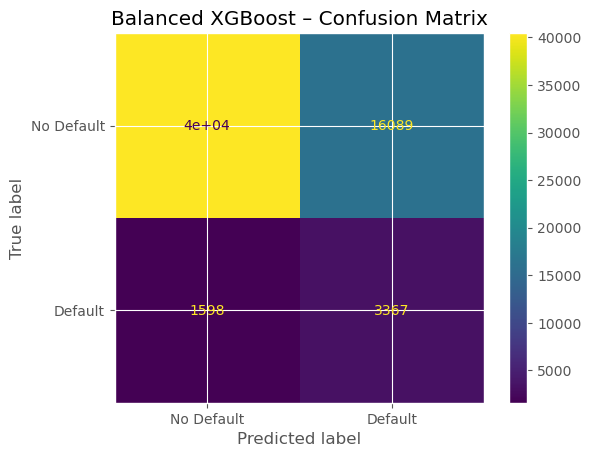

In [199]:
cm_balanced_xgb = confusion_matrix(
    Y_test,
    Y_balanced_xgb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced_xgb,
    display_labels=[
        "No Default",
        "Default"
    ]
)

disp.plot()

plt.title(
    "Balanced XGBoost – Confusion Matrix"
)

plt.show()

- Balanced XGBoost can identify ~68% of potential defaulters, but it flags too many low-risk applicants.
- The model is a strong candidate for further optimization, particularly to improve precision while maintaining high recall.

## Model Comparison

The developed models are compared using Precision, Recall, F1-score, ROC-AUC and PR-AUC.

Because the dataset is highly imbalanced, particular attention is given to Recall, F1-score and PR-AUC rather than accuracy alone.

In [202]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "Balanced Random Forest",
        "XGBoost",
        "Balanced XGBoost"
    ],
    
    "Accuracy": [
        accuracy_score(Y_test, Y_logistic_pred),
        accuracy_score(Y_test, Y_balanced_pred),
        accuracy_score(Y_test, Y_rf_pred),
        accuracy_score(Y_test, Y_balanced_rf_pred),
        accuracy_score(Y_test, Y_xgb_pred),
        accuracy_score(Y_test, Y_balanced_xgb_pred)
    ],
    
    "Precision": [
        precision_score(Y_test, Y_logistic_pred, zero_division=0),
        precision_score(Y_test, Y_balanced_pred, zero_division=0),
        precision_score(Y_test, Y_rf_pred, zero_division=0),
        precision_score(Y_test, Y_balanced_rf_pred, zero_division=0),
        precision_score(Y_test, Y_xgb_pred, zero_division=0),
        precision_score(Y_test, Y_balanced_xgb_pred, zero_division=0)
    ],
    
    "Recall": [
        recall_score(Y_test, Y_logistic_pred, zero_division=0),
        recall_score(Y_test, Y_balanced_pred, zero_division=0),
        recall_score(Y_test, Y_rf_pred, zero_division=0),
        recall_score(Y_test, Y_balanced_rf_pred, zero_division=0),
        recall_score(Y_test, Y_xgb_pred, zero_division=0),
        recall_score(Y_test, Y_balanced_xgb_pred, zero_division=0)
    ],
    
    "F1": [
        f1_score(Y_test, Y_logistic_pred, zero_division=0),
        f1_score(Y_test, Y_balanced_pred, zero_division=0),
        f1_score(Y_test, Y_rf_pred, zero_division=0),
        f1_score(Y_test, Y_balanced_rf_pred, zero_division=0),
        f1_score(Y_test, Y_xgb_pred, zero_division=0),
        f1_score(Y_test, Y_balanced_xgb_pred, zero_division=0)
    ],
    
    "ROC-AUC": [
        roc_auc_score(Y_test, logistic_model.predict_proba(X_test_processed)[:, 1]),
        roc_auc_score(Y_test, Y_balanced_prob),
        roc_auc_score(Y_test, Y_rf_prob),
        roc_auc_score(Y_test, Y_balanced_rf_prob),
        roc_auc_score(Y_test, Y_xgb_prob),
        roc_auc_score(Y_test, Y_balanced_xgb_prob)
    ],
    
    "PR-AUC": [
        average_precision_score(
            Y_test,
            logistic_model.predict_proba(X_test_processed)[:, 1]
        ),
        average_precision_score(
            Y_test,
            Y_balanced_prob
        ),
        average_precision_score(
            Y_test,
            Y_rf_prob
        ),
        average_precision_score(
            Y_test,
            Y_balanced_rf_prob
        ),
        average_precision_score(
            Y_test,
            Y_xgb_prob
        ),
        average_precision_score(
            Y_test,
            Y_balanced_xgb_prob
        )
    ]
})

In [203]:
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9196,0.6058,0.0127,0.0249,0.7506,0.2380
1,Balanced Logistic Regression,0.6896,0.1605,0.6725,0.2592,0.7505,0.2345
2,Random Forest,0.9195,0.6970,0.0046,0.0092,0.7304,0.2261
3,Balanced Random Forest,0.9193,0.5075,0.0068,0.0135,0.7421,0.2216
4,XGBoost,0.9198,0.6204,0.0171,0.0333,0.7650,0.2577
5,Balanced XGBoost,0.7124,0.1731,0.6781,0.2757,0.7648,0.2555


In [204]:
model_comparison.sort_values(by="F1",ascending=False).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
5,Balanced XGBoost,0.7124,0.1731,0.6781,0.2757,0.7648,0.2555
1,Balanced Logistic Regression,0.6896,0.1605,0.6725,0.2592,0.7505,0.2345
4,XGBoost,0.9198,0.6204,0.0171,0.0333,0.7650,0.2577
0,Logistic Regression,0.9196,0.6058,0.0127,0.0249,0.7506,0.2380
3,Balanced Random Forest,0.9193,0.5075,0.0068,0.0135,0.7421,0.2216
2,Random Forest,0.9195,0.6970,0.0046,0.0092,0.7304,0.2261


## Phase 9 – Model Development Conclusion

The experiments demonstrate that class imbalance has a major impact on model performance.

The unbalanced models achieved high accuracy but showed extremely low recall for the default class. Class weighting substantially improved the ability of Logistic Regression and XGBoost to identify defaulting applicants.

Among the evaluated models, Balanced XGBoost currently provides the strongest overall performance, achieving approximately 67.8% recall, 17.3% precision, 27.6% F1-score, 76.5% ROC-AUC and 25.6% PR-AUC.

However, the relatively low precision indicates that the model generates a considerable number of false-positive risk classifications. Therefore, further optimization is required before selecting the final decision threshold and deploying the model.

## Phase 9.1 – Validation Set

The training dataset is divided into training and validation subsets.

The training subset is used to train and tune the model, while the validation subset is used to evaluate different model configurations and classification thresholds.

The original test set is kept completely separate and will only be used for the final evaluation of the selected model.

In [207]:
from sklearn.model_selection import train_test_split

In [208]:
X_train_tune,X_val,Y_train_tune,Y_val=train_test_split(X_train_processed,Y_train,test_size=0.2,stratify=Y_train,random_state=42)

In [209]:
print("Tuning Training Shape:",X_train_tune.shape)
print("Validation Shape:",X_val.shape)

print("Tuning Target Shape:",Y_train_tune.shape)
print("Validation Target Shape:", Y_val.shape)

Tuning Training Shape: (196806, 246)
Validation Shape: (49202, 246)
Tuning Target Shape: (196806,)
Validation Target Shape: (49202,)


In [210]:
# Calculate scale_pos_weight

scale_pos_weight_tune = (
    (Y_train_tune == 0).sum() /
    (Y_train_tune == 1).sum()
)

print(
    "Scale Pos Weight:",
    scale_pos_weight_tune
)

Scale Pos Weight: 11.387084592145015


#### Train a tuning baseline

In [212]:
xgb_tuning_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight_tune,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist")

In [213]:
# Train the tuning model

xgb_tuning_model.fit(
    X_train_tune,
    Y_train_tune)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [214]:
Y_val_pred = xgb_tuning_model.predict(X_val)

In [215]:
Y_val_prob = xgb_tuning_model.predict_proba(
    X_val
)[:, 1]

#### Evaluate the validation baseline

In [217]:
print("Validation Baseline Performance")

print(
    "Accuracy:",
    accuracy_score(Y_val, Y_val_pred)
)

print(
    "Precision:",
    precision_score(
        Y_val,
        Y_val_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_val,
        Y_val_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        Y_val,
        Y_val_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        Y_val,
        Y_val_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        Y_val,
        Y_val_prob
    )
)

Validation Baseline Performance
Accuracy: 0.7099101662534043
Precision: 0.16960677400731286
Recall: 0.6656596173212488
F1 Score: 0.27033382751393076
ROC-AUC: 0.7588062296121489
PR-AUC: 0.24143001771345862


#### Create the parameter search space

In [395]:
param_grid = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# That's a lot of combinations.
#We do not want to test every possible combination.
#Instead, we'll use RandomizedSearchCV.

In [396]:
from sklearn.model_selection import RandomizedSearchCV

In [397]:
xgb_for_tuning = XGBClassifier(
    scale_pos_weight=scale_pos_weight_tune,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist"
)

In [222]:
random_search=RandomizedSearchCV( estimator=xgb_for_tuning,
    param_distributions=param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

#Why average_precision?

# This is effectively the PR-AUC-based scoring measure we're using.
# That's important because your dataset is heavily imbalanced.
# We want it to optimize performance on the minority/default class.

In [401]:
random_search.fit(X_train_tune,Y_train_tune)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'min_child_weight': [1, 5, 10],
                                        'n_estimators': [200, 300, 400],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='average_precision', verbose=1)

In [405]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [407]:
print("Best Cross-Validation PR-AUC:",random_search.best_score_)

Best Cross-Validation PR-AUC: 0.24666321438792968


In [409]:
best_xgb=random_search.best_estimator_

In [411]:
Y_val_best_prob = best_xgb.predict_proba(
    X_val
)[:, 1]

Y_val_best_pred = best_xgb.predict(
    X_val
)

In [413]:
print("Optimized XGBoost - Validation Performance")

print("Accuracy:",
      accuracy_score(Y_val, Y_val_best_pred))

print("Precision:",
      precision_score(Y_val, Y_val_best_pred, zero_division=0))

print("Recall:",
      recall_score(Y_val, Y_val_best_pred, zero_division=0))

print("F1 Score:",
      f1_score(Y_val, Y_val_best_pred, zero_division=0))

print("ROC-AUC:",
      roc_auc_score(Y_val, Y_val_best_prob))

print("PR-AUC:",
      average_precision_score(Y_val, Y_val_best_prob))

Optimized XGBoost - Validation Performance
Accuracy: 0.7221454412422259
Precision: 0.17494470138749246
Recall: 0.6570996978851964
F1 Score: 0.27632205812291566
ROC-AUC: 0.7630764288778914
PR-AUC: 0.24612230099022642


In [415]:
print(
    classification_report(
        Y_val,
        Y_val_best_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.96      0.73      0.83     45230
     Default       0.17      0.66      0.28      3972

    accuracy                           0.72     49202
   macro avg       0.57      0.69      0.55     49202
weighted avg       0.90      0.72      0.78     49202



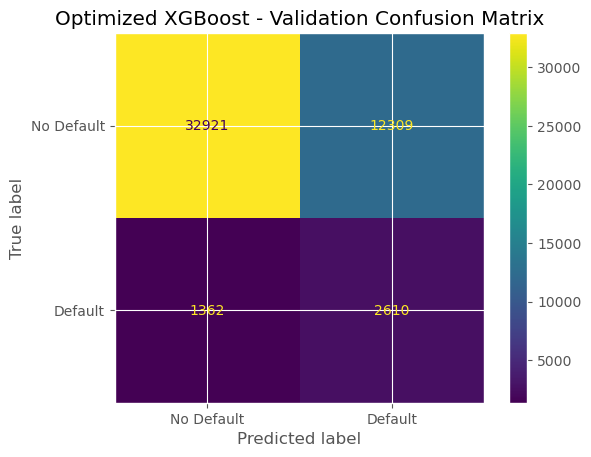

In [320]:
cm_best_xgb = confusion_matrix(
    Y_val,
    Y_val_best_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_xgb,
    display_labels=[
        "No Default",
        "Default"
    ]
)

disp.plot()

plt.title("Optimized XGBoost - Validation Confusion Matrix")
plt.show()                                                                                                 

## Threshold Optimization

The default classification threshold of 0.50 may not be optimal for a highly imbalanced credit-risk problem.

Different probability thresholds are evaluated to understand the trade-off between precision and recall.

A lower threshold can identify more potential defaulters, but may also increase false-positive classifications. The threshold will therefore be selected based on the desired balance between risk detection and unnecessary rejection.

In [417]:
Y_val_best_prob

array([0.40212294, 0.16385637, 0.15266609, ..., 0.56426483, 0.18115768,
       0.35149178], dtype=float32)

#### Testing different thresholds

In [454]:
import numpy as np

print(np.arange(0.10, 0.60, 0.05))

[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]


In [456]:
thresholds=np.linspace(0.10,0.60,11)

In [458]:
print(thresholds)

[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6 ]


In [470]:
threshold_results=[]
for threshold in thresholds:
    Y_threshold_pred = (Y_val_best_prob >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            Y_val,
            Y_threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            Y_val,
            Y_threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            Y_val,
            Y_threshold_pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.10,0.0853,0.9950,0.1571
1,0.15,0.0912,0.9801,0.1668
2,0.20,0.0989,0.9559,0.1793
3,0.25,0.1086,0.9247,0.1944
4,0.30,0.1199,0.8882,0.2112
5,0.35,0.1321,0.8434,0.2284
6,0.40,0.1453,0.7890,0.2454
7,0.45,0.1599,0.7266,0.2621
8,0.50,0.1749,0.6571,0.2763
9,0.55,0.1935,0.5866,0.2910


In [474]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold_row.round(4)

Threshold    0.6000
Precision    0.2137
Recall       0.5118
F1           0.3015
Name: 10, dtype: float64

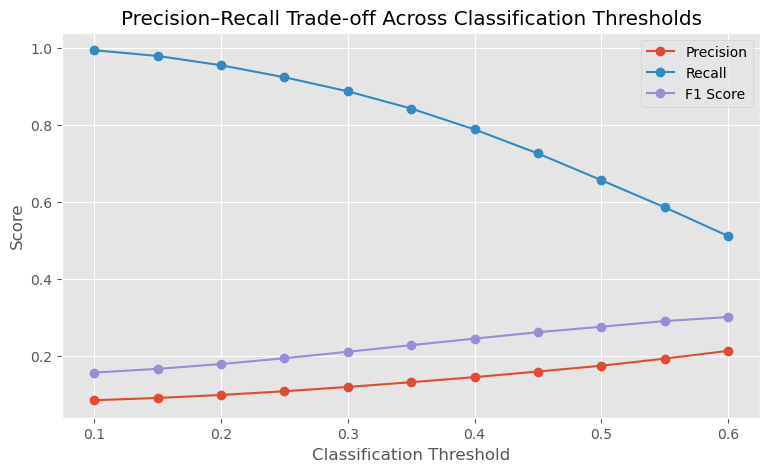

In [476]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off Across Classification Thresholds")

plt.legend()
plt.grid(True)

plt.show()

At 0.60, the model has its best F1 among the thresholds you tested, but it catches only 51.18% of actual defaulters.

For a credit-risk project, that's a problem if our objective is to minimize missed risky borrowers.

Next step: extend the threshold analysis

In [481]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    
    Y_threshold_pred = (
        Y_val_best_prob >= threshold
    ).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            Y_val,
            Y_threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            Y_val,
            Y_threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            Y_val,
            Y_threshold_pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.10,0.0853,0.9950,0.1571
1,0.15,0.0912,0.9801,0.1668
2,0.20,0.0989,0.9559,0.1793
3,0.25,0.1086,0.9247,0.1944
4,0.30,0.1199,0.8882,0.2112
5,0.35,0.1321,0.8434,0.2284
6,0.40,0.1453,0.7890,0.2454
7,0.45,0.1599,0.7266,0.2621
8,0.50,0.1749,0.6571,0.2763
9,0.55,0.1935,0.5866,0.2910


In [483]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold_row.round(4)

Threshold    0.7000
Precision    0.2716
Recall       0.3588
F1           0.3091
Name: 12, dtype: float64

##### Final Decision-

Threshold Selection – 0.60

A probability threshold of 0.60 was selected as the operating threshold because it provides a good balance between precision (21.37%) and recall (51.18%), while maintaining strong detection of potential loan defaulters. This helps reduce the risk of approving high-risk applicants while avoiding excessive false rejections.

In [487]:
final_threshold = 0.60

Y_val_final_pred = (
    Y_val_best_prob >= final_threshold
).astype(int)

In [489]:
print("Final Threshold:", final_threshold)

print("Precision:",
      precision_score(Y_val, Y_val_final_pred))

print("Recall:",
      recall_score(Y_val, Y_val_final_pred))

print("F1 Score:",
      f1_score(Y_val, Y_val_final_pred))

Final Threshold: 0.6
Precision: 0.21368509564851798
Recall: 0.5118328298086606
F1 Score: 0.30149784962183007


In [493]:
print(
    classification_report(
        Y_val,
        Y_val_final_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.95      0.83      0.89     45230
     Default       0.21      0.51      0.30      3972

    accuracy                           0.81     49202
   macro avg       0.58      0.67      0.60     49202
weighted avg       0.89      0.81      0.84     49202



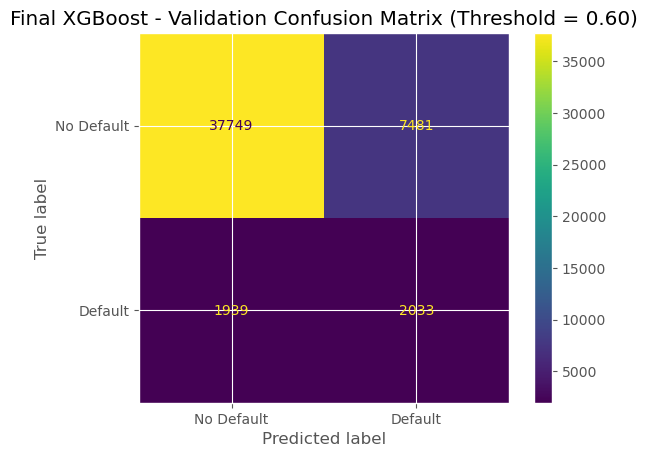

In [495]:
cm_final = confusion_matrix(
    Y_val,
    Y_val_final_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=[
        "No Default",
        "Default"
    ]
)

disp.plot()

plt.title(
    "Final XGBoost - Validation Confusion Matrix (Threshold = 0.60)"
)

plt.show()

### PHASE 10 — Final Model Evaluation on Test Data

In [500]:
Y_test_best_prob = best_xgb.predict_proba( X_test_processed)[:, 1]

print("Test probabilities generated successfully.")

print("First 10 probabilities:")
print(Y_test_best_prob[:10])

Test probabilities generated successfully.
First 10 probabilities:
[0.32038555 0.33103168 0.7638503  0.36372718 0.51490694 0.5486189
 0.13117607 0.06624333 0.8498293  0.5451266 ]


In [504]:

# STEP 2 — Apply Final Threshold
final_threshold = 0.60

Y_test_final_pred = (
    Y_test_best_prob >= final_threshold
).astype(int)

print("\nFinal Threshold:", final_threshold)


Final Threshold: 0.6


In [506]:
# STEP 3 — Calculate Final Test Performance
# ------------------------------------------------------------

print("\nFinal XGBoost Test Performance")

print(
    "Accuracy:",
    accuracy_score(
        Y_test,
        Y_test_final_pred
    )
)

print(
    "Precision:",
    precision_score(
        Y_test,
        Y_test_final_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        Y_test,
        Y_test_final_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        Y_test,
        Y_test_final_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        Y_test,
        Y_test_best_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        Y_test,
        Y_test_best_prob
    )
)


Final XGBoost Test Performance
Accuracy: 0.8140415914670829
Precision: 0.2218975592987281
Recall: 0.5200402819738167
F1 Score: 0.3110655984579242
ROC-AUC: 0.7687240749985119
PR-AUC: 0.25794108326368553


In [508]:
print("\nClassification Report")

print(
    classification_report(
        Y_test,
        Y_test_final_pred,
        target_names=[
            "No Default",
            "Default"
        ],
        zero_division=0
    )
)



Classification Report
              precision    recall  f1-score   support

  No Default       0.95      0.84      0.89     56538
     Default       0.22      0.52      0.31      4965

    accuracy                           0.81     61503
   macro avg       0.59      0.68      0.60     61503
weighted avg       0.89      0.81      0.85     61503



In [510]:
cm_test = confusion_matrix(
    Y_test,
    Y_test_final_pred
)

print("\nConfusion Matrix:")
print(cm_test)



Confusion Matrix:
[[47484  9054]
 [ 2383  2582]]


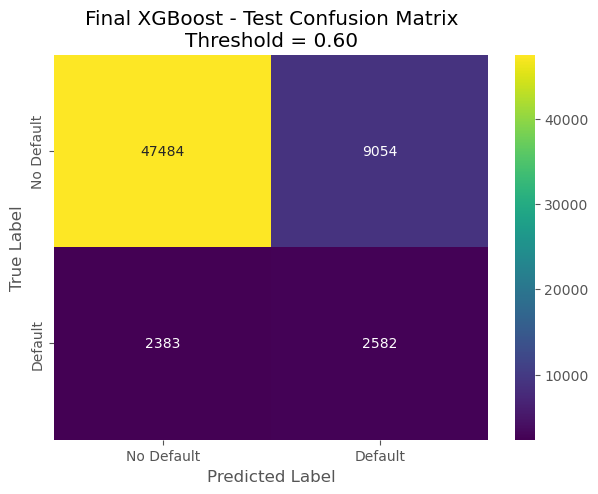

In [512]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=[
        "No Default",
        "Default"
    ],
    yticklabels=[
        "No Default",
        "Default"
    ]
)

plt.title(
    "Final XGBoost - Test Confusion Matrix\n"
    "Threshold = 0.60"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Final XGBoost – Key Insights

- **Accuracy: 81.4%** → Overall prediction performance is good, but accuracy is not the main metric due to class imbalance.

- **Recall: 52%** → The model identifies **about half of the actual defaulters**, reducing the risk of missing high-risk customers.

- **Precision: 22.2%** → About **1 in 5 customers flagged as defaulters actually default**, so some customers will be unnecessarily flagged.

- **F1-score: 31.1%** → Shows a reasonable balance between identifying defaulters and avoiding false alarms, but there is still room for improvement.

- **ROC-AUC: 76.9%** → The model has a **good ability to distinguish between defaulters and non-defaulters**.

- **PR-AUC: 25.8%** → Indicates useful performance on the minority **default class**, which is more meaningful than accuracy for this imbalanced daset.

### 🎯 Business Insight

> **The model is suitable as a risk-screening tool because it identifies around 52% of potential defaulters. However, flagged customers should undergo additional credit assessment because of the relatively low precision.**

## Phase 11 – Model Explainability

Model explainability is used to understand which applicant features have the greatest influence on loan default predictions.

This is important in credit-risk applications because stakeholders need to understand the factors contributing to a model's risk assessment rather than relying only on a prediction.

We first examine the global feature importance of the optimized XGBoost model.

In [526]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:10])

246
['num__CNT_CHILDREN' 'num__AMT_INCOME_TOTAL' 'num__AMT_CREDIT'
 'num__AMT_ANNUITY' 'num__AMT_GOODS_PRICE'
 'num__REGION_POPULATION_RELATIVE' 'num__DAYS_BIRTH' 'num__DAYS_EMPLOYED'
 'num__DAYS_REGISTRATION' 'num__DAYS_ID_PUBLISH']


In [528]:
feature_importance = best_xgb.feature_importances_

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.round(4)


,Feature,Importance
95,num__EXT_SOURCE_MEAN,0.0629
103,cat__CODE_GENDER_M,0.0137
96,num__EXT_SOURCE_MIN,0.0132
125,cat__NAME_EDUCATION_TYPE_Higher education,0.0131
102,cat__CODE_GENDER_F,0.0121
...,...,...
80,num__FLAG_DOCUMENT_19,0.0000
176,cat__ORGANIZATION_TYPE_Emergency,0.0000
175,cat__ORGANIZATION_TYPE_Electricity,0.0000
111,cat__NAME_TYPE_SUITE_Group of people,0.0000


In [532]:
importance_df.head(20)

,Feature,Importance
95,num__EXT_SOURCE_MEAN,0.062930
103,cat__CODE_GENDER_M,0.013650
96,num__EXT_SOURCE_MIN,0.013169
125,cat__NAME_EDUCATION_TYPE_Higher education,0.013101
102,cat__CODE_GENDER_F,0.012124
97,num__EXT_SOURCE_MAX,0.011693
123,cat__NAME_INCOME_TYPE_Working,0.011296
29,num__EXT_SOURCE_3,0.010294
128,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.010113
94,num__CREDIT_GOODS_RATIO,0.009604


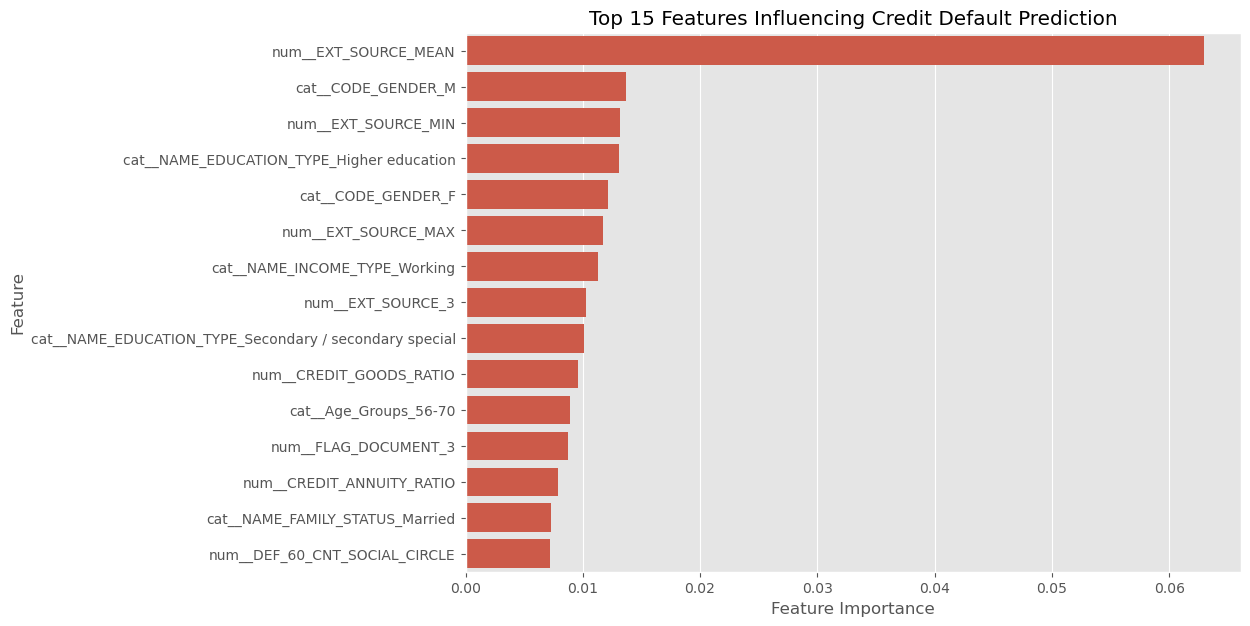

In [534]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Influencing Credit Default Prediction"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

### Final Model Interpretation

The optimized XGBoost model was selected as the final model after
hyperparameter tuning and threshold optimization.

At the selected classification threshold of 0.60, the model identifies
approximately 52% of actual loan defaulters. This improves the ability
to detect risky applicants, although the relatively low precision means
that some low-risk applicants may also be flagged.

Therefore, the model should be used as a risk-screening and decision-
support tool rather than as the sole basis for loan approval or rejection.

## Business Recommendations

1. **Use the model as a risk-screening tool**
   
   Applicants predicted as high risk should receive additional credit
   assessment rather than being automatically rejected.

2. **Prioritize applicants with stronger credit-risk indicators**
   
   The model's feature-importance results show that external credit-related
   indicators are highly influential in predicting default risk.

3. **Introduce enhanced review for high-risk applicants**
   
   Applications above the selected risk threshold of 0.60 can be routed
   for additional verification or manual assessment.

4. **Balance risk detection with customer experience**
   
   Since the model has a recall of 52% and precision of 22.19%, it can
   identify a substantial proportion of defaulters but also produces
   false-positive risk flags. Therefore, automated rejection should be
   avoided.

5. **Use model predictions alongside existing credit policies**
   
   The model should support, rather than completely replace, established
   lending rules, verification procedures and human credit assessment.

### PHASE 14 — CREDIT RISK SCORING SYSTEM

In [546]:
def classify_risk(probability):
    
    if probability >= 0.60:
        return "HIGH RISK"
    else:
        return "LOWER RISK"

In [548]:
print(classify_risk(0.75))
print(classify_risk(0.35))

HIGH RISK
LOWER RISK


In [550]:
def loan_recommendation(probability):
    
    if probability >= 0.60:
        return "ADDITIONAL REVIEW REQUIRED"
    else:
        return "PROCEED WITH STANDARD ASSESSMENT"

In [552]:
print(loan_recommendation(0.75))
print(loan_recommendation(0.35))

ADDITIONAL REVIEW REQUIRED
PROCEED WITH STANDARD ASSESSMENT


#### Create a Risk Score

In [555]:
def calculate_risk_score(probability):
    
    return round(probability * 100, 2)

#### Test the Complete System

In [559]:
def credit_risk_assessment(probability):
    
    risk_score = calculate_risk_score(probability)
    risk_category = classify_risk(probability)
    recommendation = loan_recommendation(probability)
    
    return {
        "Default Probability": round(probability * 100, 2),
        "Risk Score": risk_score,
        "Risk Category": risk_category,
        "Recommendation": recommendation
    }

In [561]:
credit_risk_assessment(0.724)

{'Default Probability': 72.4,
 'Risk Score': 72.4,
 'Risk Category': 'HIGH RISK',
 'Recommendation': 'ADDITIONAL REVIEW REQUIRED'}

#### Apply It to Your Test Applicants

In [566]:
# Final default probability for each test applicant
Y_test_final_prob = best_xgb.predict_proba(
    X_test_processed
)[:, 1]

print("First 10 Default Probabilities:")
print(Y_test_final_prob[:10])

First 10 Default Probabilities:
[0.32038555 0.33103168 0.7638503  0.36372718 0.51490694 0.5486189
 0.13117607 0.06624333 0.8498293  0.5451266 ]


In [570]:
risk_results = pd.DataFrame({
    "Default Probability": Y_test_final_prob,
    "Risk Score": Y_test_final_prob * 100
})

risk_results["Risk Category"] = risk_results[
    "Default Probability"
].apply(classify_risk)

risk_results["Recommendation"] = risk_results[
    "Default Probability"
].apply(loan_recommendation)

risk_results.head(10)

,Default Probability,Risk Score,Risk Category,Recommendation
0,0.320386,32.038555,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT
1,0.331032,33.103168,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT
2,0.763850,76.385025,HIGH RISK,ADDITIONAL REVIEW REQUIRED
3,0.363727,36.372719,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT
4,0.514907,51.490696,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT
5,0.548619,54.861893,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT
6,0.131176,13.117607,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT
7,0.066243,6.624333,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT
8,0.849829,84.982933,HIGH RISK,ADDITIONAL REVIEW REQUIRED
9,0.545127,54.512661,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT


#### Create Risk Bands

In [585]:
def risk_band(probability):
    
    if probability < 0.30:
        return "LOW RISK"
    
    elif probability < 0.60:
        return "MEDIUM RISK"
    
    else:
        return "HIGH RISK"

In [587]:
risk_results["Risk Band"] = (
    Y_test_best_prob
    .astype(float)
)

risk_results["Risk Band"] = risk_results[
    "Risk Band"
].apply(risk_band)

risk_results.head(10)

,Default Probability,Risk Score,Risk Category,Recommendation,Risk Band
0,320400.0,32.040001,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT,MEDIUM RISK
1,331000.0,33.099998,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT,MEDIUM RISK
2,763900.0,76.389999,HIGH RISK,ADDITIONAL REVIEW REQUIRED,HIGH RISK
3,363700.0,36.369999,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT,MEDIUM RISK
4,514900.0,51.490002,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT,MEDIUM RISK
5,548600.0,54.860001,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT,MEDIUM RISK
6,131200.0,13.120000,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT,LOW RISK
7,66200.0,6.620000,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT,LOW RISK
8,849800.0,84.980003,HIGH RISK,ADDITIONAL REVIEW REQUIRED,HIGH RISK
9,545100.0,54.509998,LOWER RISK,PROCEED WITH STANDARD ASSESSMENT,MEDIUM RISK


In [589]:
final_risk_table = pd.DataFrame({
    "Default Probability (%)":
        (Y_test_best_prob * 100).round(2),

    "Risk Score":
        (Y_test_best_prob * 100).round(2)
})

final_risk_table["Risk Band"] = (
    Y_test_best_prob.apply(risk_band)
    if isinstance(Y_test_best_prob, pd.Series)
    else [risk_band(x) for x in Y_test_best_prob]
)

final_risk_table["Recommendation"] = [
    loan_recommendation(x)
    for x in Y_test_best_prob
]

final_risk_table.head(10)

,Default Probability (%),Risk Score,Risk Band,Recommendation
0,32.040001,32.040001,MEDIUM RISK,PROCEED WITH STANDARD ASSESSMENT
1,33.099998,33.099998,MEDIUM RISK,PROCEED WITH STANDARD ASSESSMENT
2,76.389999,76.389999,HIGH RISK,ADDITIONAL REVIEW REQUIRED
3,36.369999,36.369999,MEDIUM RISK,PROCEED WITH STANDARD ASSESSMENT
4,51.490002,51.490002,MEDIUM RISK,PROCEED WITH STANDARD ASSESSMENT
5,54.860001,54.860001,MEDIUM RISK,PROCEED WITH STANDARD ASSESSMENT
6,13.120000,13.120000,LOW RISK,PROCEED WITH STANDARD ASSESSMENT
7,6.620000,6.620000,LOW RISK,PROCEED WITH STANDARD ASSESSMENT
8,84.980003,84.980003,HIGH RISK,ADDITIONAL REVIEW REQUIRED
9,54.509998,54.509998,MEDIUM RISK,PROCEED WITH STANDARD ASSESSMENT


### Risk Distribution

In [592]:
risk_distribution = risk_results["Risk Band"].value_counts()

print("Risk Distribution:")
print(risk_distribution)

Risk Distribution:
Risk Band
MEDIUM RISK    25106
LOW RISK       24761
HIGH RISK      11636
Name: count, dtype: int64


In [594]:
risk_percentage = (
    risk_results["Risk Band"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Risk Distribution (%):")
print(risk_percentage)

Risk Distribution (%):
Risk Band
MEDIUM RISK    40.82
LOW RISK       40.26
HIGH RISK      18.92
Name: proportion, dtype: float64


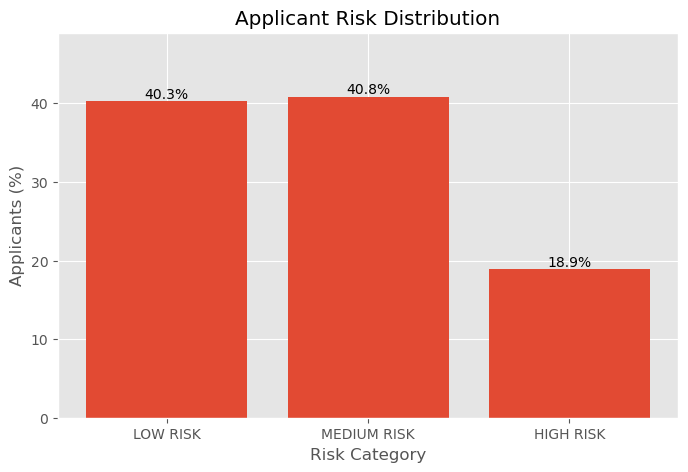

In [596]:
import matplotlib.pyplot as plt

risk_percentage = risk_percentage.reindex(
    ["LOW RISK", "MEDIUM RISK", "HIGH RISK"]
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    risk_percentage.index,
    risk_percentage.values
)

plt.title("Applicant Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Applicants (%)")

plt.ylim(0, max(risk_percentage.values) * 1.2)

for bar, value in zip(bars, risk_percentage.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

In [598]:
high_risk_count = (
    risk_results["Risk Band"] == "HIGH RISK"
).sum()

total_applicants = len(risk_results)

high_risk_percentage = (
    high_risk_count / total_applicants
) * 100

print("Total Applicants:", total_applicants)
print("High Risk Applicants:", high_risk_count)
print("High Risk Percentage:", round(high_risk_percentage, 2), "%")

Total Applicants: 61503
High Risk Applicants: 11636
High Risk Percentage: 18.92 %


In [602]:
def assess_applicant(applicant_data):

    # Preprocess applicant data
    applicant_processed = preprocessor.transform(applicant_data)

    # Predict probability of default
    default_probability = best_xgb.predict_proba(
        applicant_processed
    )[:, 1][0]

    # Risk score
    risk_score = round(default_probability * 100, 2)

    # Risk band
    risk_category = risk_band(default_probability)

    # Recommendation
    recommendation = loan_recommendation(default_probability)

    print("========================================")
    print("       CREDIT RISK ASSESSMENT")
    print("========================================")

    print(f"Default Probability : {risk_score}%")
    print(f"Risk Score          : {risk_score}/100")
    print(f"Risk Band           : {risk_category}")
    print(f"Recommendation      : {recommendation}")

    print("========================================")

    return {
        "Default Probability (%)": risk_score,
        "Risk Score": risk_score,
        "Risk Band": risk_category,
        "Recommendation": recommendation
    }

In [604]:
# Select one applicant from the test dataset
sample_applicant = X_test.iloc[[0]]

# Assess credit risk
assessment = assess_applicant(sample_applicant)

       CREDIT RISK ASSESSMENT
Default Probability : 32.04%
Risk Score          : 32.04/100
Risk Band           : MEDIUM RISK
Recommendation      : PROCEED WITH STANDARD ASSESSMENT


## PHASE 15 — BUILD THE CREDIT RISK PREDICTION INTERFACE

In [608]:
import joblib

joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [610]:
import os

print(os.path.exists("best_xgb_model.pkl"))
print(os.path.exists("preprocessor.pkl"))

True
True


In [612]:
joblib.dump(X_train, "X_train_reference.pkl")

print("Training reference data saved.")

Training reference data saved.


In [640]:
import streamlit as st
import pandas as pd
import joblib


# =========================================================
# LOAD MODEL, PREPROCESSOR AND REFERENCE DATA
# =========================================================

model = joblib.load("best_xgb_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")
X_train = joblib.load("X_train_reference.pkl")


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Credit Risk Prediction System",
    page_icon="💳",
    layout="wide"
)


# =========================================================
# TITLE
# =========================================================

st.title("💳 Credit Risk Prediction System")

st.write(
    "AI-based loan default prediction and applicant "
    "risk assessment system."
)

st.divider()


# =========================================================
# RISK FUNCTIONS
# =========================================================

def risk_band(probability):

    if probability < 0.30:
        return "LOW RISK"

    elif probability < 0.60:
        return "MEDIUM RISK"

    else:
        return "HIGH RISK"


def loan_recommendation(probability):

    if probability >= 0.60:
        return "ADDITIONAL REVIEW REQUIRED"

    else:
        return "PROCEED WITH STANDARD ASSESSMENT"


# =========================================================
# APPLICANT INPUT
# =========================================================

st.header("Applicant Information")

st.write(
    "Enter the applicant's information and click "
    "**Assess Credit Risk**."
)


# Create empty dictionary
input_data = {}


# =========================================================
# CREATE INPUT FIELDS
# =========================================================

with st.form("credit_risk_form"):

    # ---------------------------------------------
    # Numerical Features
    # ---------------------------------------------

    st.subheader("Financial and Numerical Information")

    numerical_features = X_train.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    for feature in numerical_features:

        default_value = X_train[feature].median()

        input_data[feature] = st.number_input(
            feature,
            value=float(default_value)
        )


    # ---------------------------------------------
    # Categorical Features
    # ---------------------------------------------

    st.subheader("Personal and Categorical Information")

    categorical_features = X_train.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    for feature in categorical_features:

        options = (
            X_train[feature]
            .dropna()
            .unique()
            .tolist()
        )

        if len(options) > 0:

            input_data[feature] = st.selectbox(
                feature,
                options
            )


    # ---------------------------------------------
    # Prediction Button
    # ---------------------------------------------

    submitted = st.form_submit_button(
        "🔍 Assess Credit Risk"
    )


# =========================================================
# PREDICTION
# =========================================================

if submitted:

    applicant_df = pd.DataFrame(
        [input_data],
        columns=X_train.columns
    )


    # ---------------------------------------------
    # Preprocessing
    # ---------------------------------------------

    applicant_processed = preprocessor.transform(
        applicant_df
    )


    # ---------------------------------------------
    # Default Probability
    # ---------------------------------------------

    probability = model.predict_proba(
        applicant_processed
    )[0][1]


    # ---------------------------------------------
    # Risk Score
    # ---------------------------------------------

    risk_score = round(
        probability * 100,
        2
    )


    # ---------------------------------------------
    # Risk Classification
    # ---------------------------------------------

    category = risk_band(probability)

    recommendation = loan_recommendation(
        probability
    )


    # =================================================
    # DISPLAY RESULTS
    # =================================================

    st.divider()

    st.header("Credit Risk Assessment")

    col1, col2, col3 = st.columns(3)

    with col1:

        st.metric(
            "Default Probability",
            f"{risk_score}%"
        )

    with col2:

        st.metric(
            "Risk Score",
            f"{risk_score}/100"
        )

    with col3:

        st.metric(
            "Risk Band",
            category
        )


    st.subheader("Recommendation")

    if category == "HIGH RISK":

        st.error(
            f"⚠️ {recommendation}"
        )

    elif category == "MEDIUM RISK":

        st.warning(
            f"⚠️ {recommendation}"
        )

    else:

        st.success(
            f"✅ {recommendation}"
        )

FileNotFoundError: [Errno 2] No such file or directory: 'best_xgb_model.pkl'

In [618]:
cd Desktop\Credit_Risk_Project

[WinError 2] The system cannot find the file specified: 'Desktop\\Credit_Risk_Project'
C:\Users\bhati


In [628]:
import os

os.chdir(r"C:\Users\bhati\Credit_Default_Project")

print(os.getcwd())

C:\Users\bhati\Credit_Default_Project


In [630]:
print(os.getcwd())

C:\Users\bhati\Credit_Default_Project


In [632]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [634]:
joblib.dump(best_xgb, "final_xgb_model.pkl")

print("Final XGBoost model saved successfully.")

Final XGBoost model saved successfully.


In [636]:
import os

print("Preprocessor exists:", os.path.exists("preprocessor.pkl"))
print("Model exists:", os.path.exists("final_xgb_model.pkl"))

Preprocessor exists: True
Model exists: True


In [638]:
print(os.getcwd())
print(os.listdir())

C:\Users\bhati\Credit_Default_Project
['final_xgb_model.pkl', 'preprocessor.pkl']


In [642]:
joblib.dump(X_train, "X_train_reference.pkl")

print("X_train reference saved successfully.")

X_train reference saved successfully.


In [644]:
import os

print("Model:", os.path.exists("final_xgb_model.pkl"))
print("Preprocessor:", os.path.exists("preprocessor.pkl"))
print("X_train reference:", os.path.exists("X_train_reference.pkl"))

Model: True
Preprocessor: True
X_train reference: True
